In [21]:
data(co2)

In [22]:
co2

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
1959,315.42,316.31,316.50,317.56,318.13,318.00,316.39,314.65,313.68,313.18,314.66,315.43
1960,316.27,316.81,317.42,318.87,319.87,319.43,318.01,315.74,314.00,313.68,314.84,316.03
1961,316.73,317.54,318.38,319.31,320.42,319.61,318.42,316.63,314.83,315.16,315.94,316.85
1962,317.78,318.40,319.53,320.42,320.85,320.45,319.45,317.25,316.11,315.27,316.53,317.53
1963,318.58,318.92,319.70,321.22,322.08,321.31,319.58,317.61,316.05,315.83,316.91,318.20
1964,319.41,320.07,320.74,321.40,322.06,321.73,320.27,318.54,316.54,316.71,317.53,318.55
1965,319.27,320.28,320.73,321.97,322.00,321.71,321.05,318.71,317.66,317.14,318.70,319.25
1966,320.46,321.43,322.23,323.54,323.91,323.59,322.24,320.20,318.48,317.94,319.63,320.87
1967,322.17,322.34,322.88,324.25,324.83,323.93,322.38,320.76,319.10,319.24,320.56,321.80
1968,322.40,322.99,323.73,324.86,325.40,325.20,323.98,321.95,320.18,320.09,321.16,322.74


In [23]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

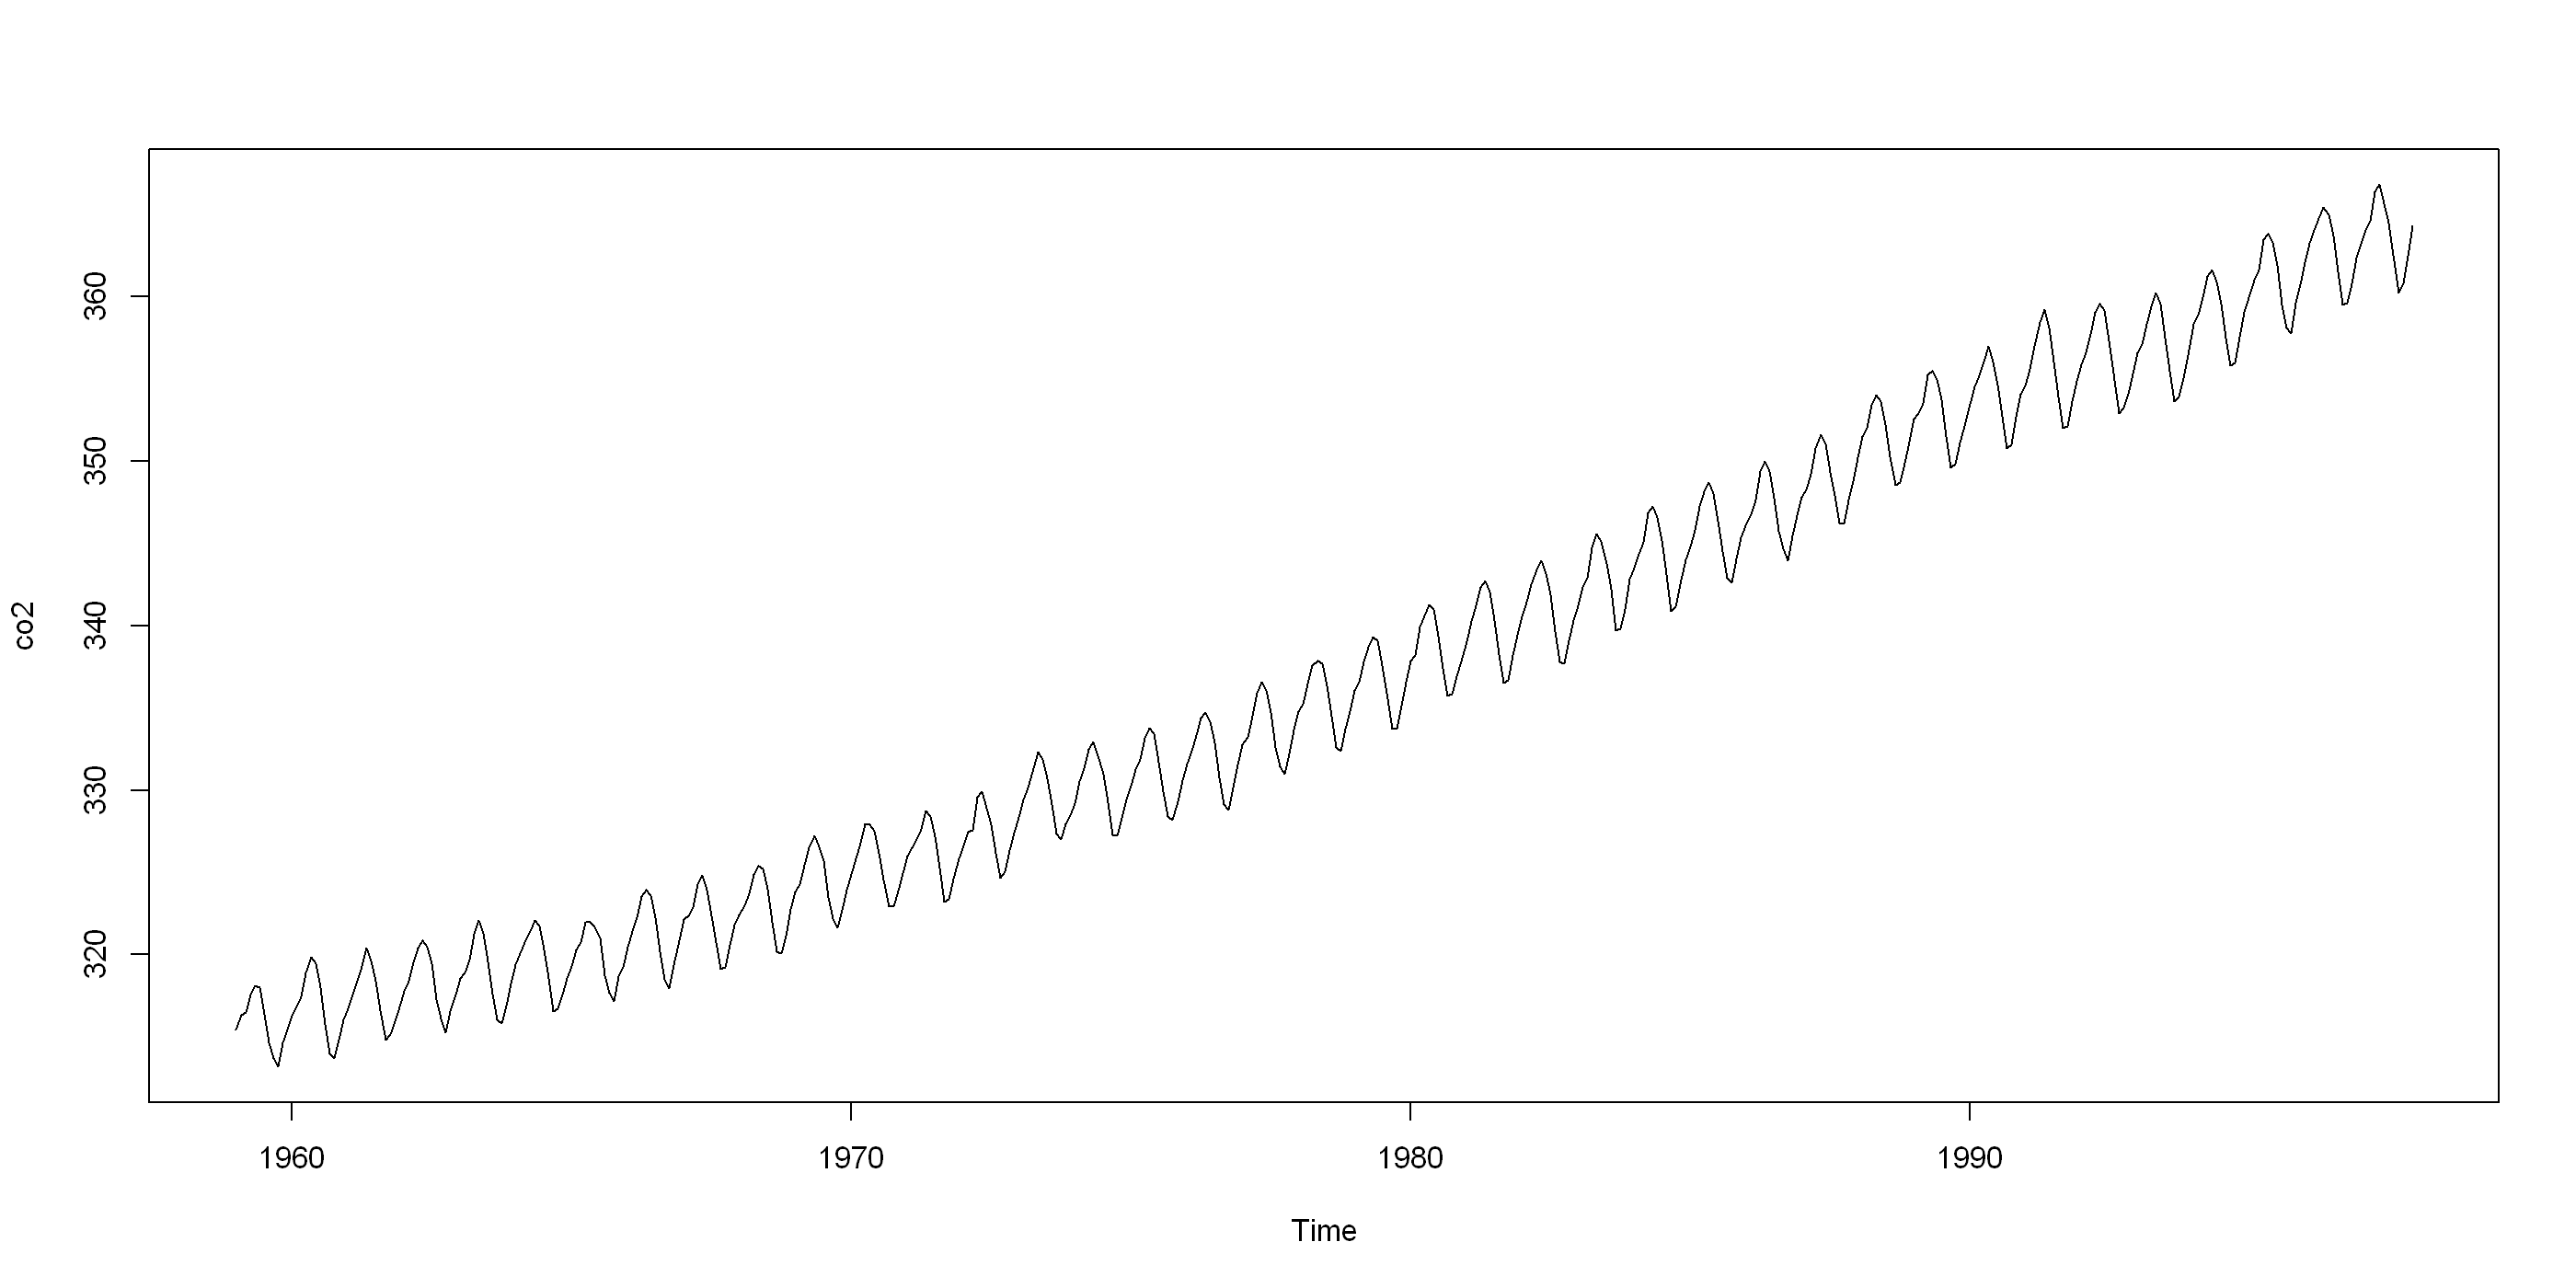

In [24]:
plot(co2)

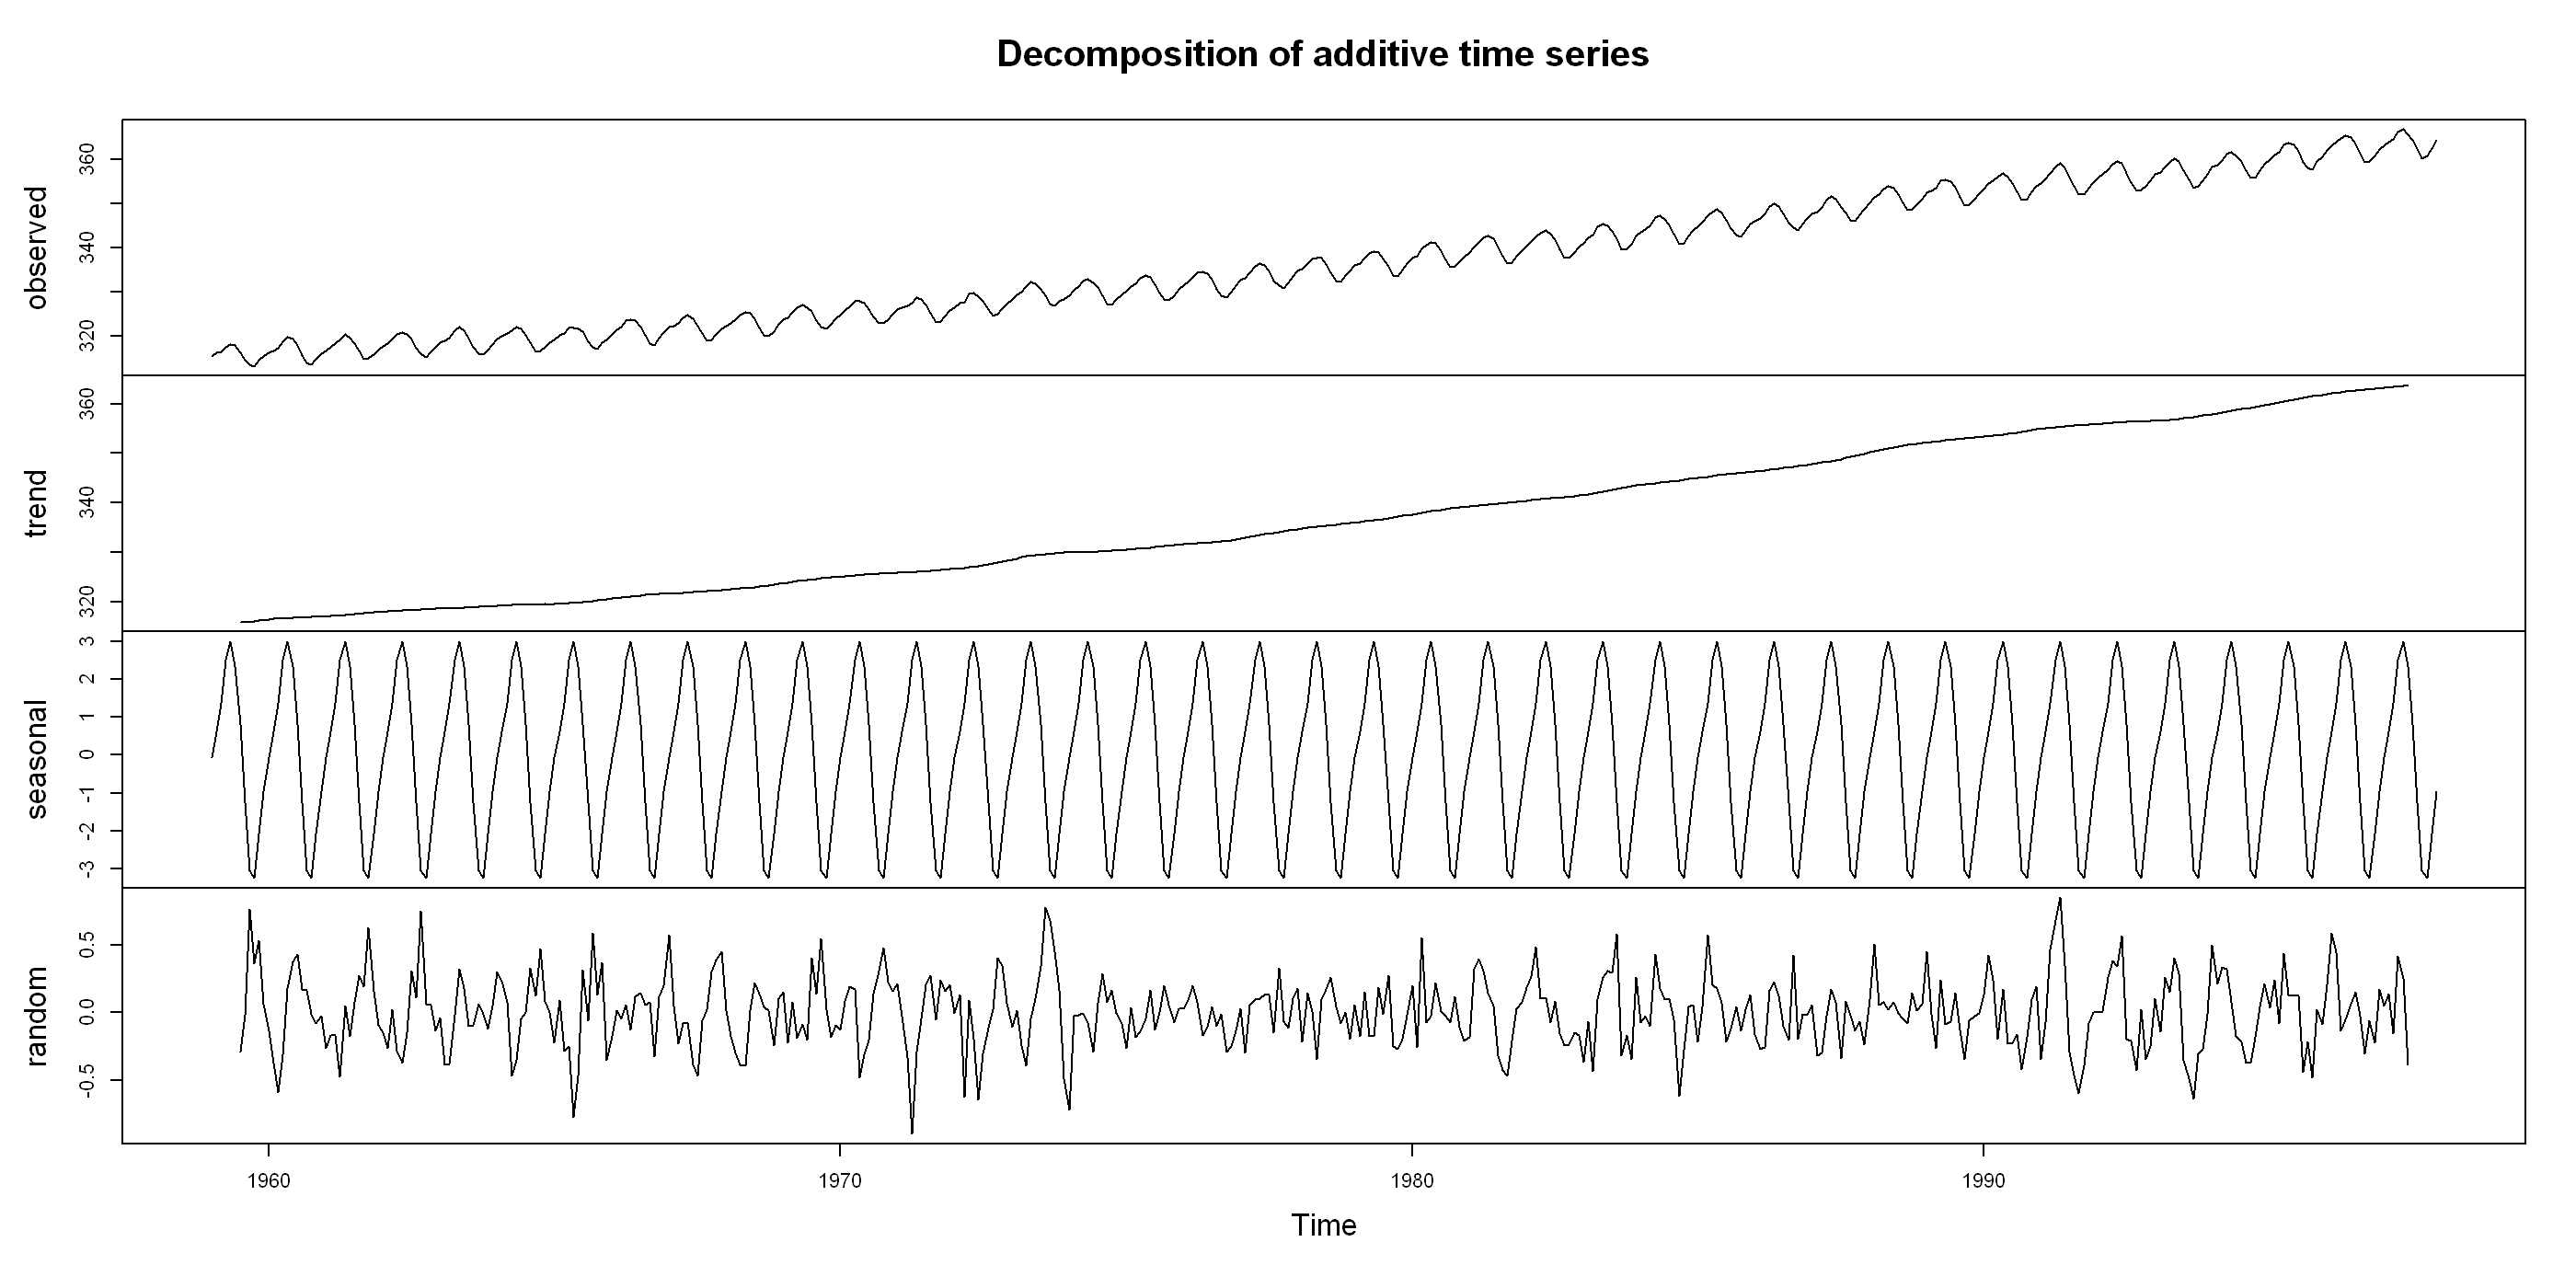

In [25]:
plot(decompose(co2))

In [26]:
library(mgcv)

Loading required package: nlme

This is mgcv 1.8-42. For overview type 'help("mgcv-package")'.



In [44]:
tr <- as.numeric(time(co2));months <- factor(cycle(co2))
fit <- gam(co2 ~ s(tr)+months)

In [28]:
print(tr)

  [1] 1959.000 1959.083 1959.167 1959.250 1959.333 1959.417 1959.500 1959.583
  [9] 1959.667 1959.750 1959.833 1959.917 1960.000 1960.083 1960.167 1960.250
 [17] 1960.333 1960.417 1960.500 1960.583 1960.667 1960.750 1960.833 1960.917
 [25] 1961.000 1961.083 1961.167 1961.250 1961.333 1961.417 1961.500 1961.583
 [33] 1961.667 1961.750 1961.833 1961.917 1962.000 1962.083 1962.167 1962.250
 [41] 1962.333 1962.417 1962.500 1962.583 1962.667 1962.750 1962.833 1962.917
 [49] 1963.000 1963.083 1963.167 1963.250 1963.333 1963.417 1963.500 1963.583
 [57] 1963.667 1963.750 1963.833 1963.917 1964.000 1964.083 1964.167 1964.250
 [65] 1964.333 1964.417 1964.500 1964.583 1964.667 1964.750 1964.833 1964.917
 [73] 1965.000 1965.083 1965.167 1965.250 1965.333 1965.417 1965.500 1965.583
 [81] 1965.667 1965.750 1965.833 1965.917 1966.000 1966.083 1966.167 1966.250
 [89] 1966.333 1966.417 1966.500 1966.583 1966.667 1966.750 1966.833 1966.917
 [97] 1967.000 1967.083 1967.167 1967.250 1967.333 1967.417 1967

In [29]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)

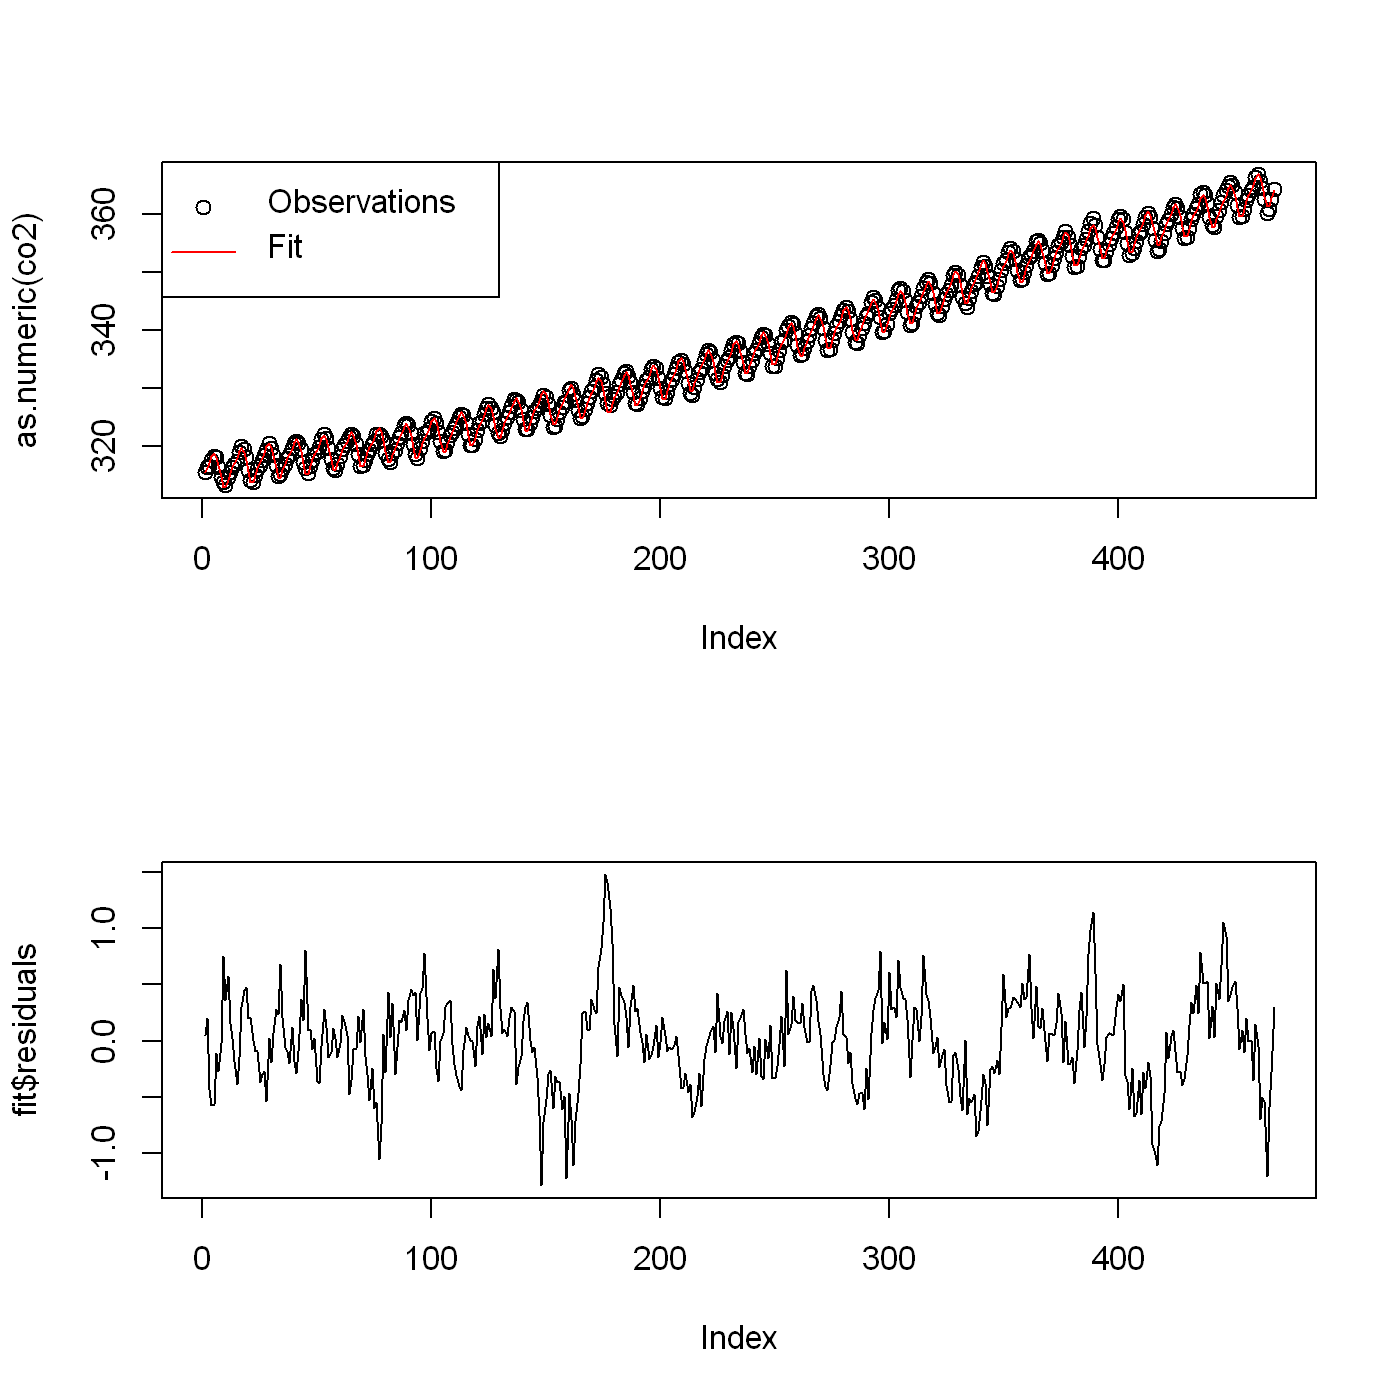

In [30]:
par(mfrow = c(2,1))
plot(as.numeric(co2))
lines(fit$fitted.values,col="red")
legend("topleft", legend = c("Observations","Fit"), lty=c(NA,1), pch=c(1,NA),col=c("black","red"))
plot(fit$residuals,type = "l")

In [45]:
fit2 <- gam(co2 ~ s(tr) + sin(2*pi*tr)+ cos(2*pi*tr))

In [32]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

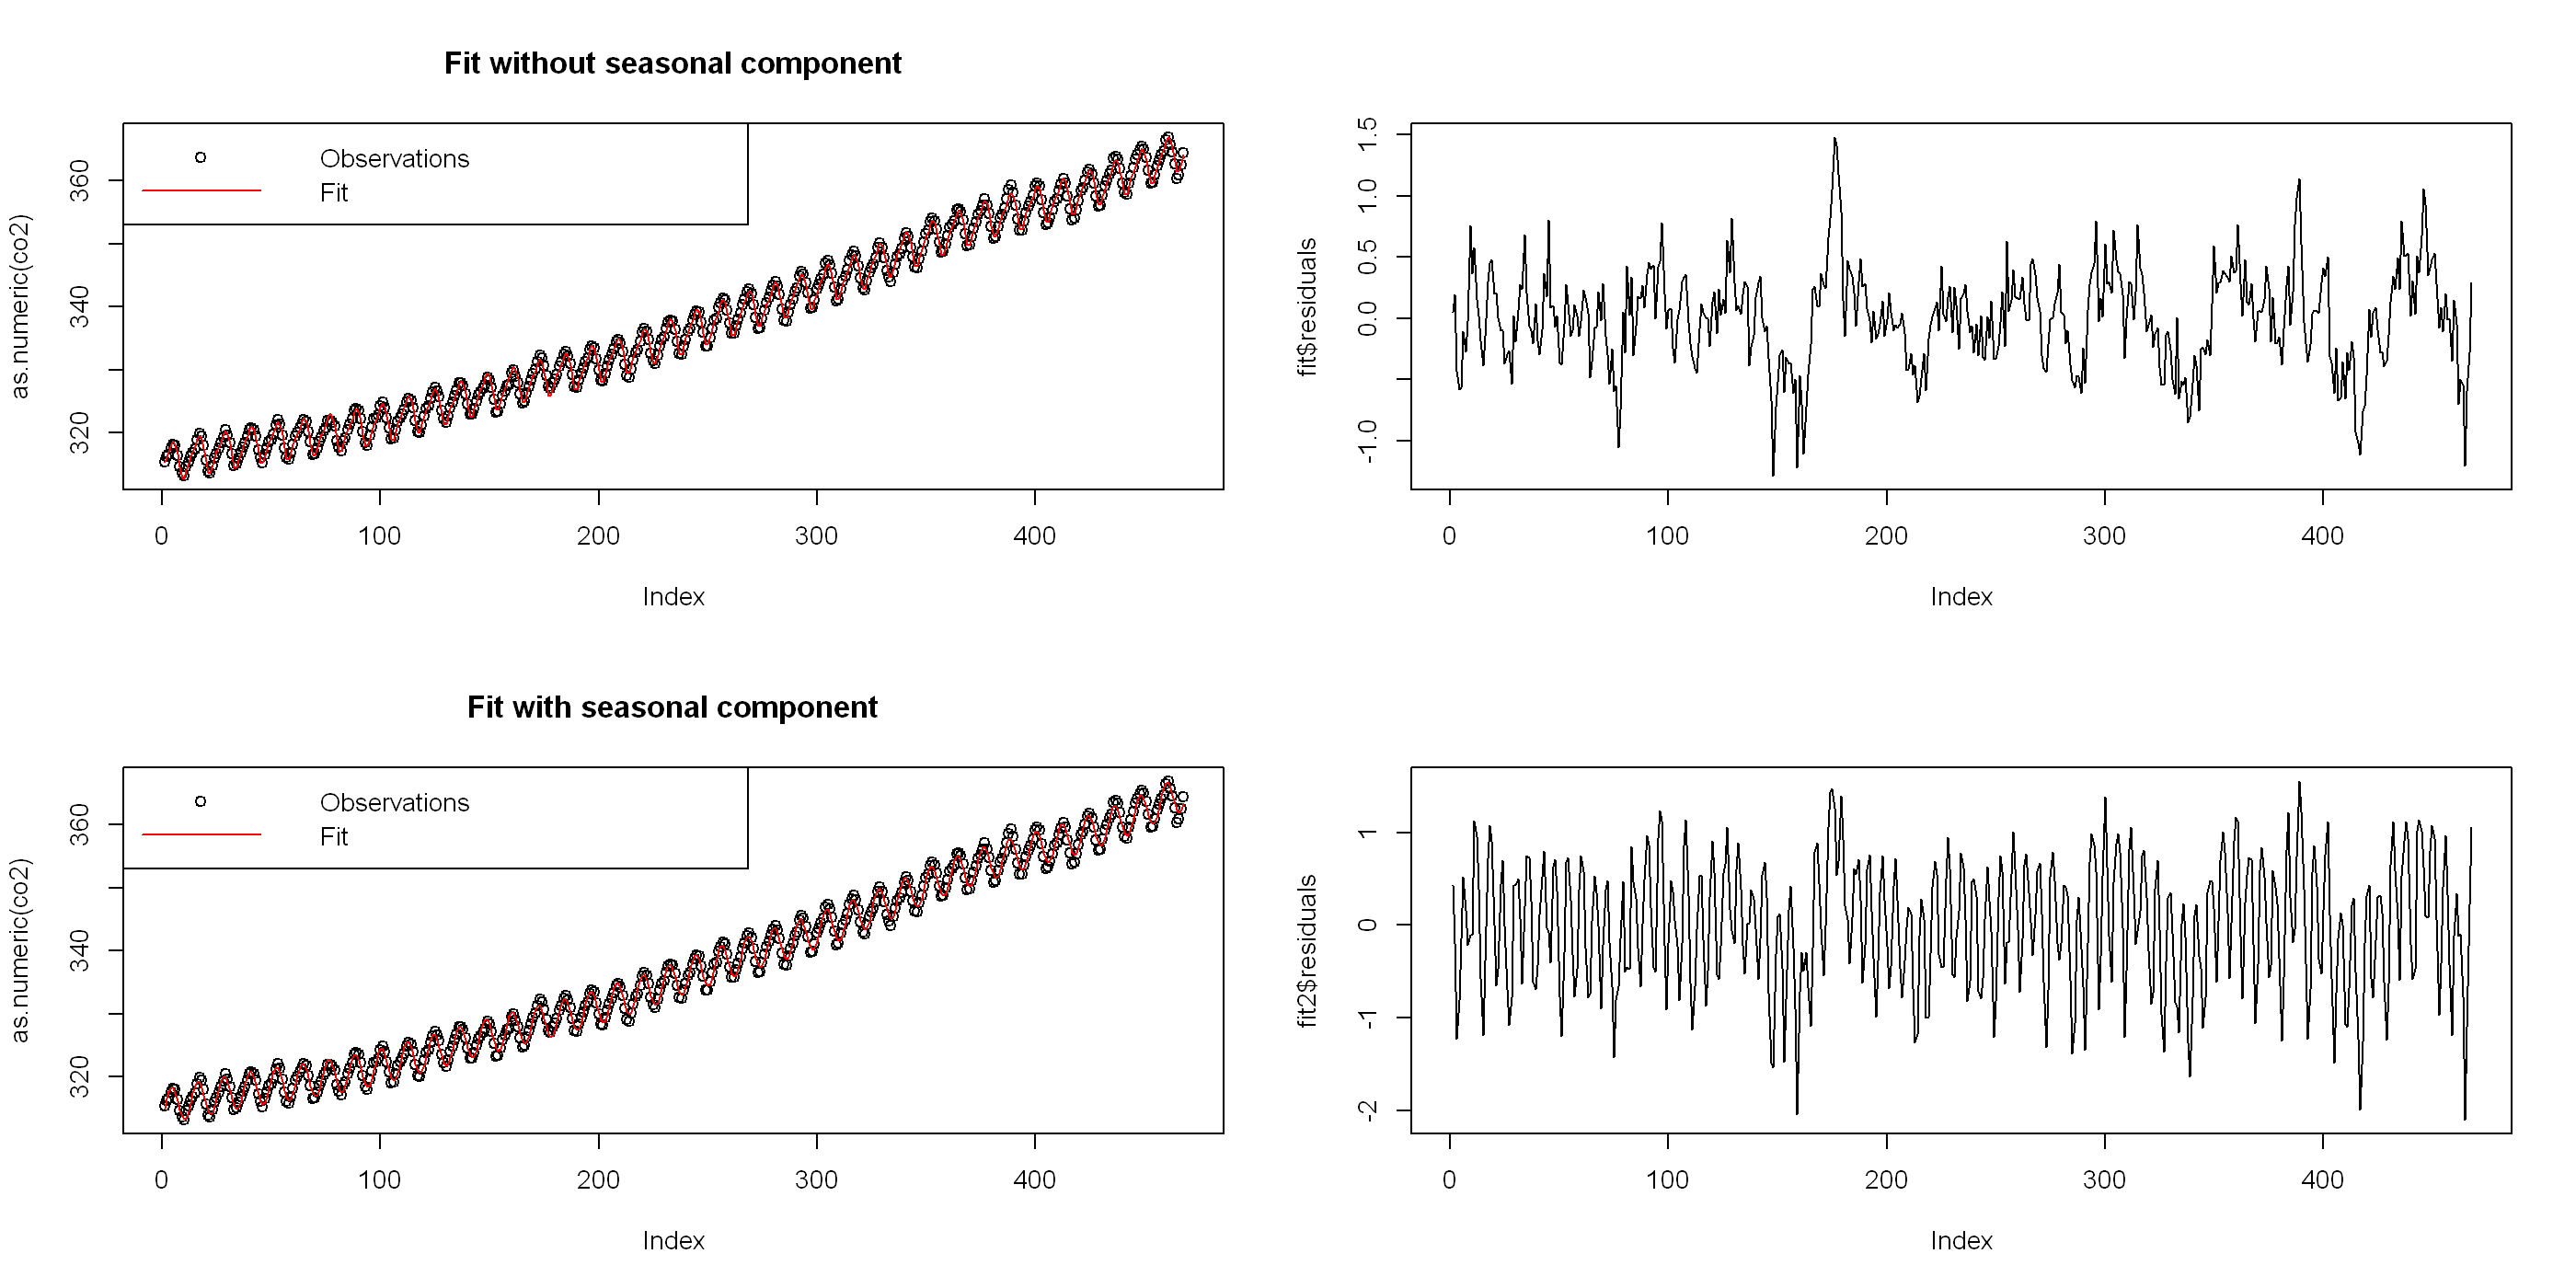

In [33]:
par(mfrow = c(2,2))
plot(as.numeric(co2),main="Fit without seasonal component")
lines(fit$fitted.values,col="red")
legend("topleft", legend = c("Observations","Fit"), lty=c(NA,1), pch=c(1,NA),col=c("black","red"))
plot(fit$residuals,type = "l")

plot(as.numeric(co2),main="Fit with seasonal component")
lines(fit2$fitted.values,col="red")
legend("topleft", legend = c("Observations","Fit"), lty=c(NA,1), pch=c(1,NA),col=c("black","red"))
plot(fit2$residuals,type = "l")

In [34]:
hstart <- read.table("https://stat.ethz.ch/Teaching/Datasets/WBL/hstart.dat")
hstart <- ts(hstart[, 1], start = c(1996,1), frequency = 12)

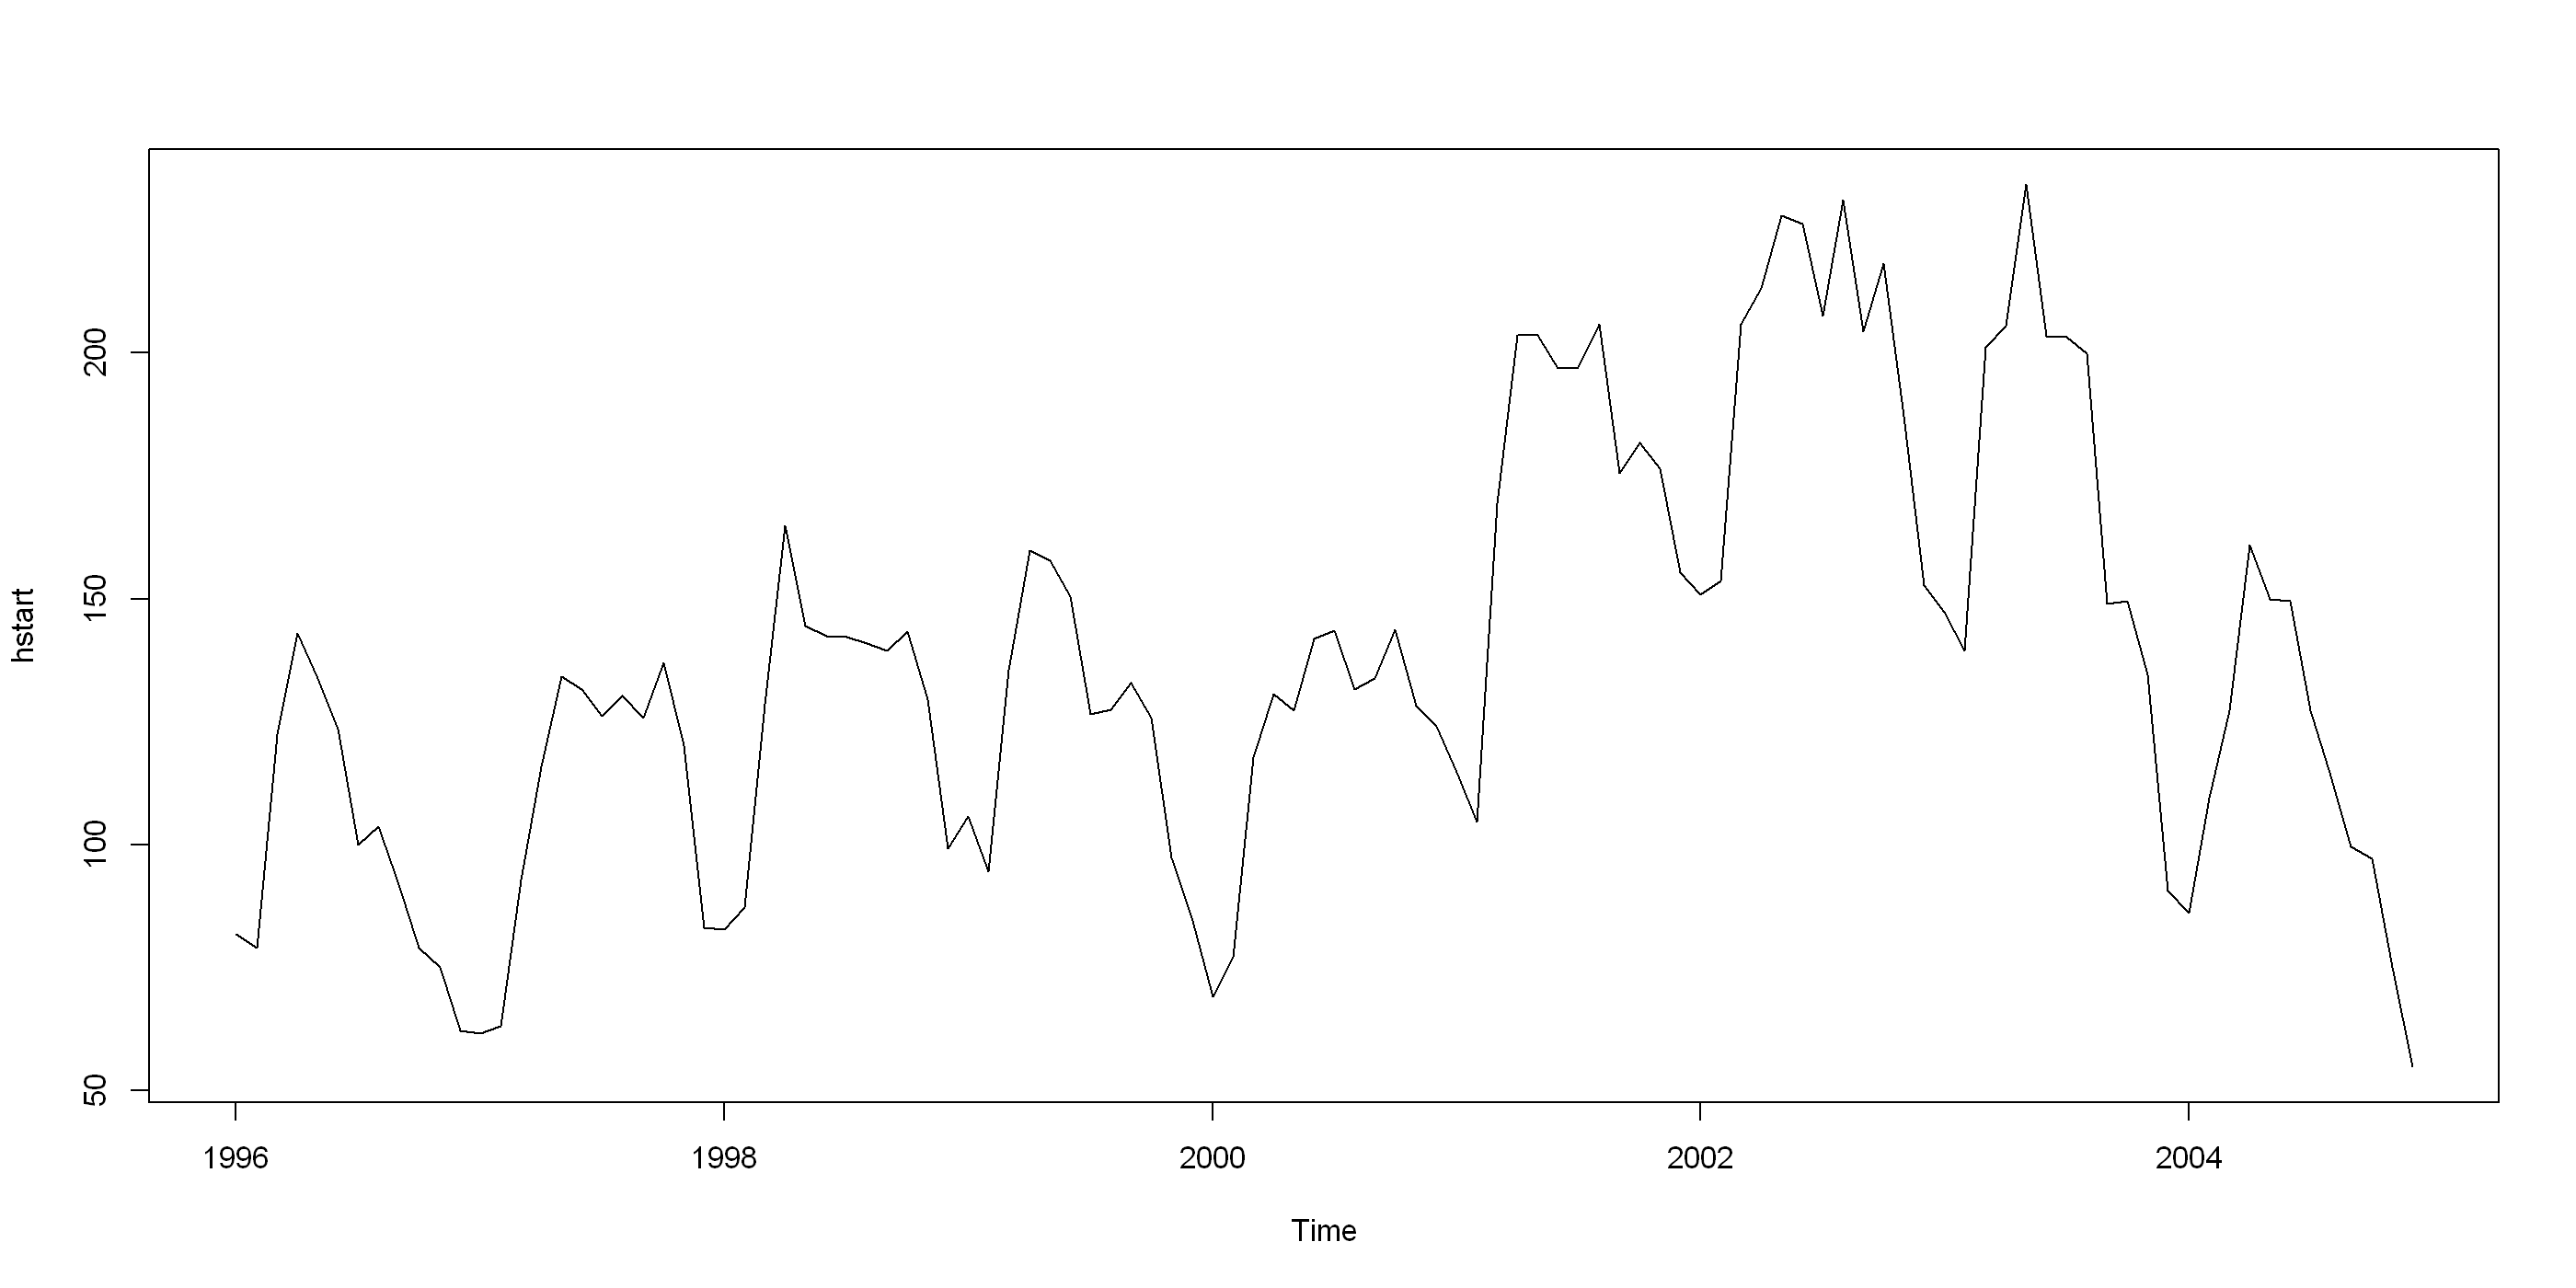

In [35]:
plot(hstart)

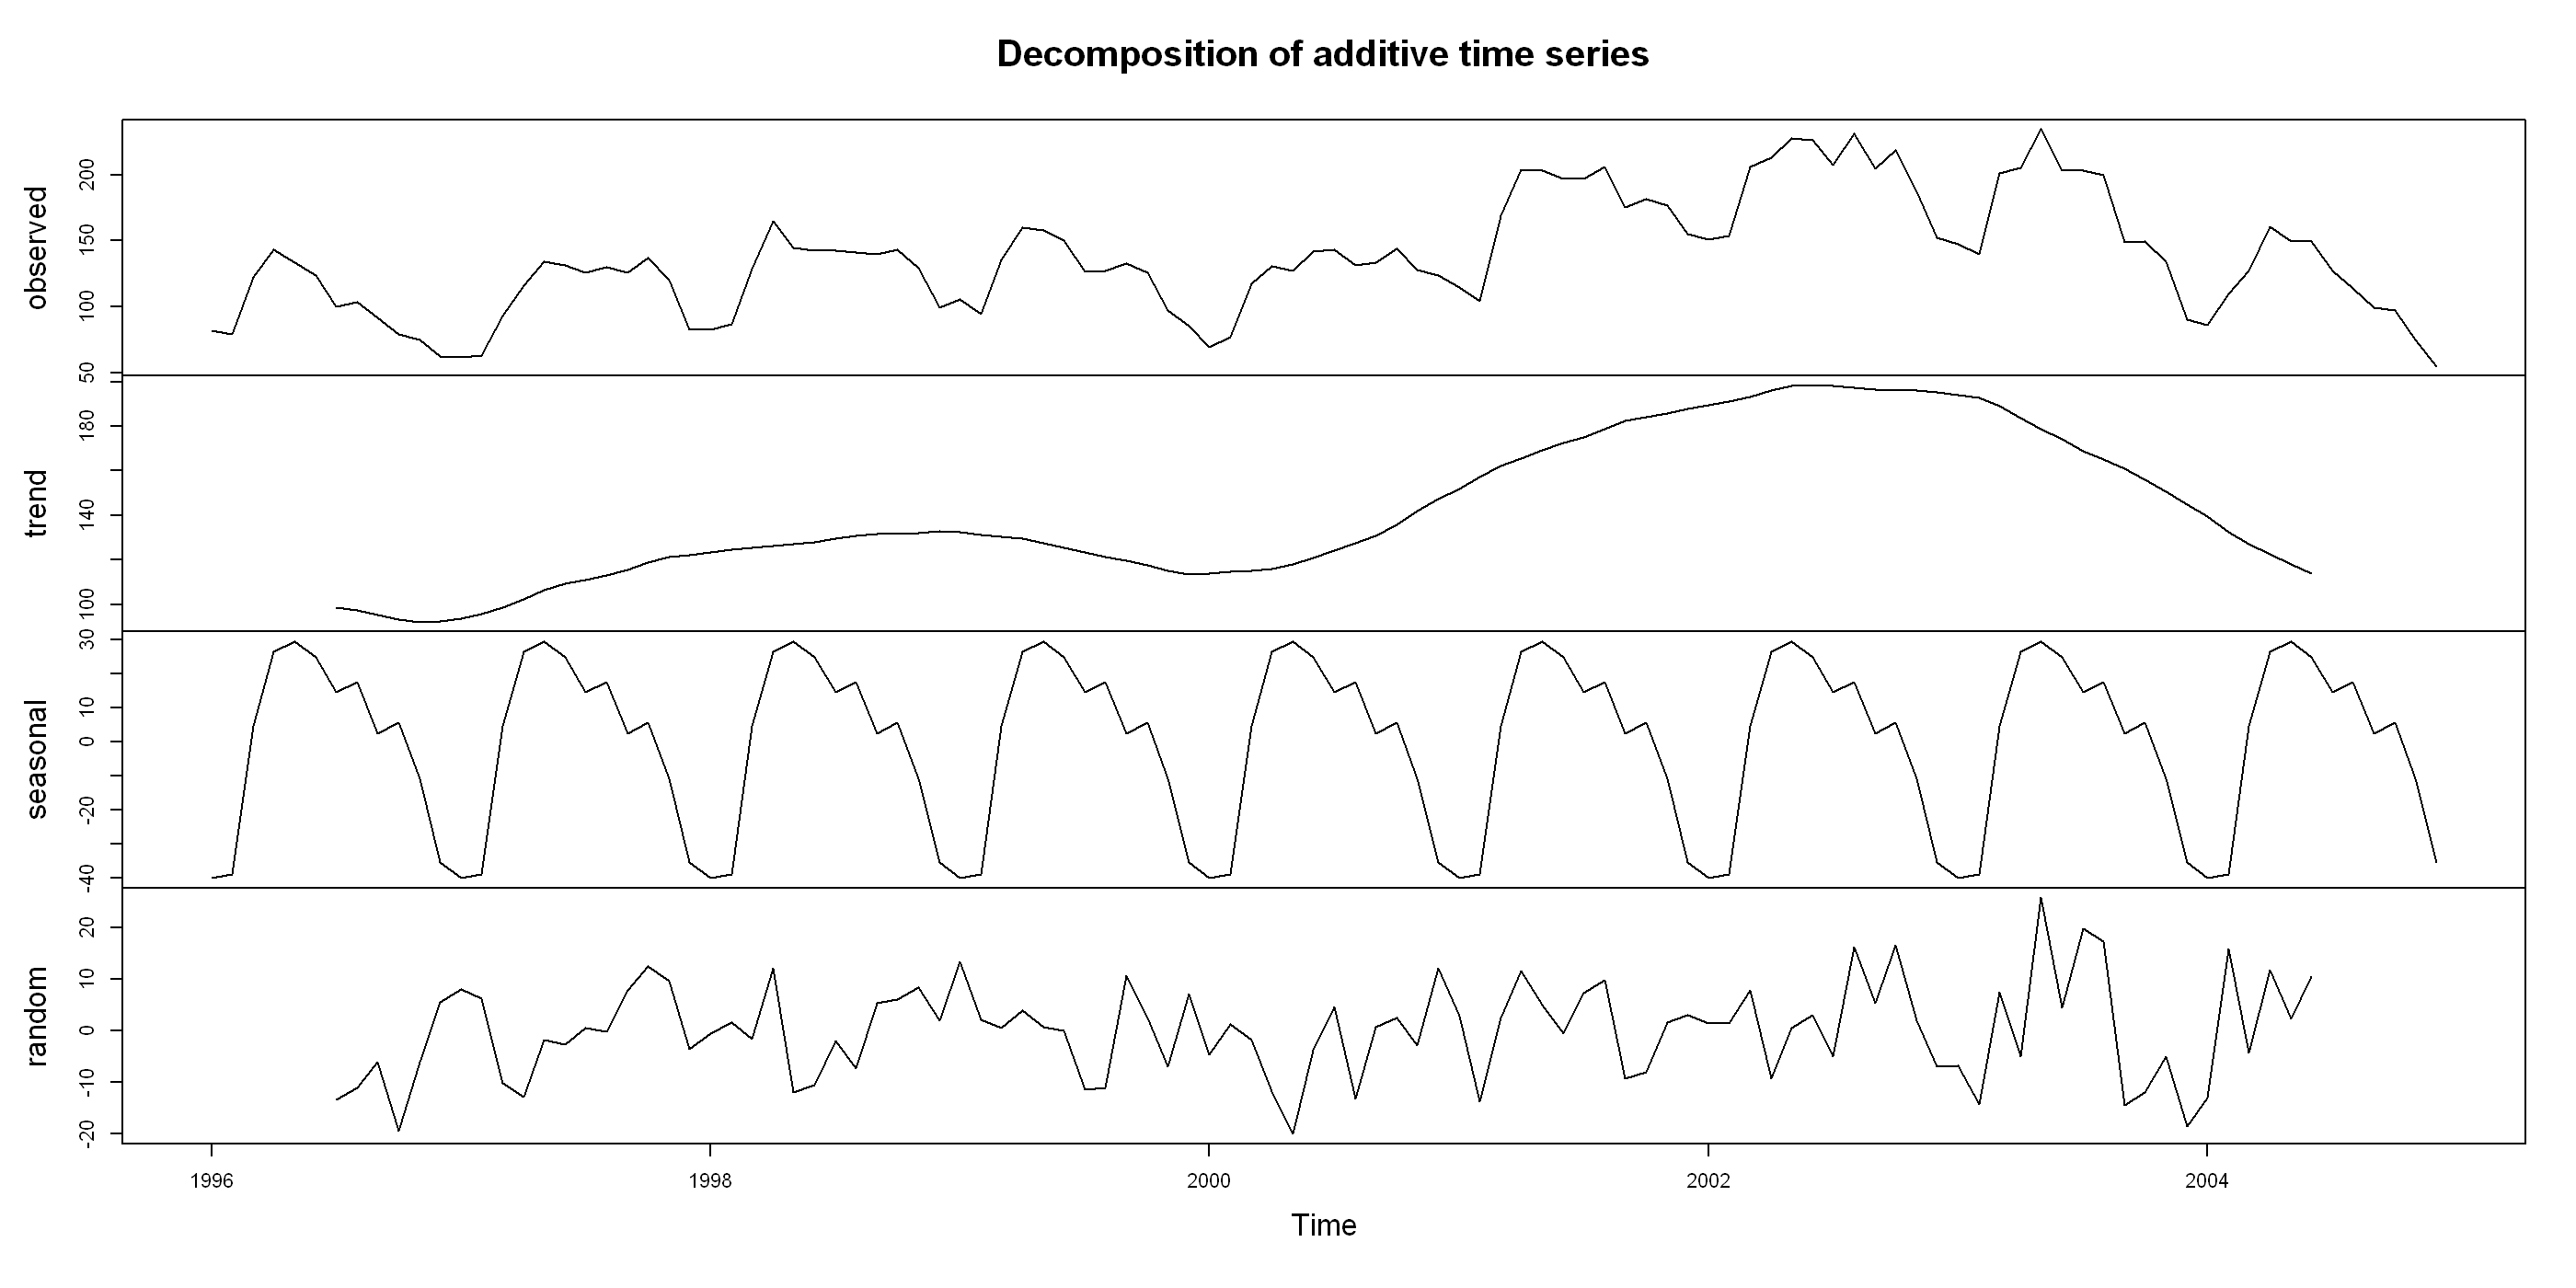

In [47]:
plot(decompose(hstart))

In [65]:
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)
par(mfrow=c(3,1),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2,lwd=2)

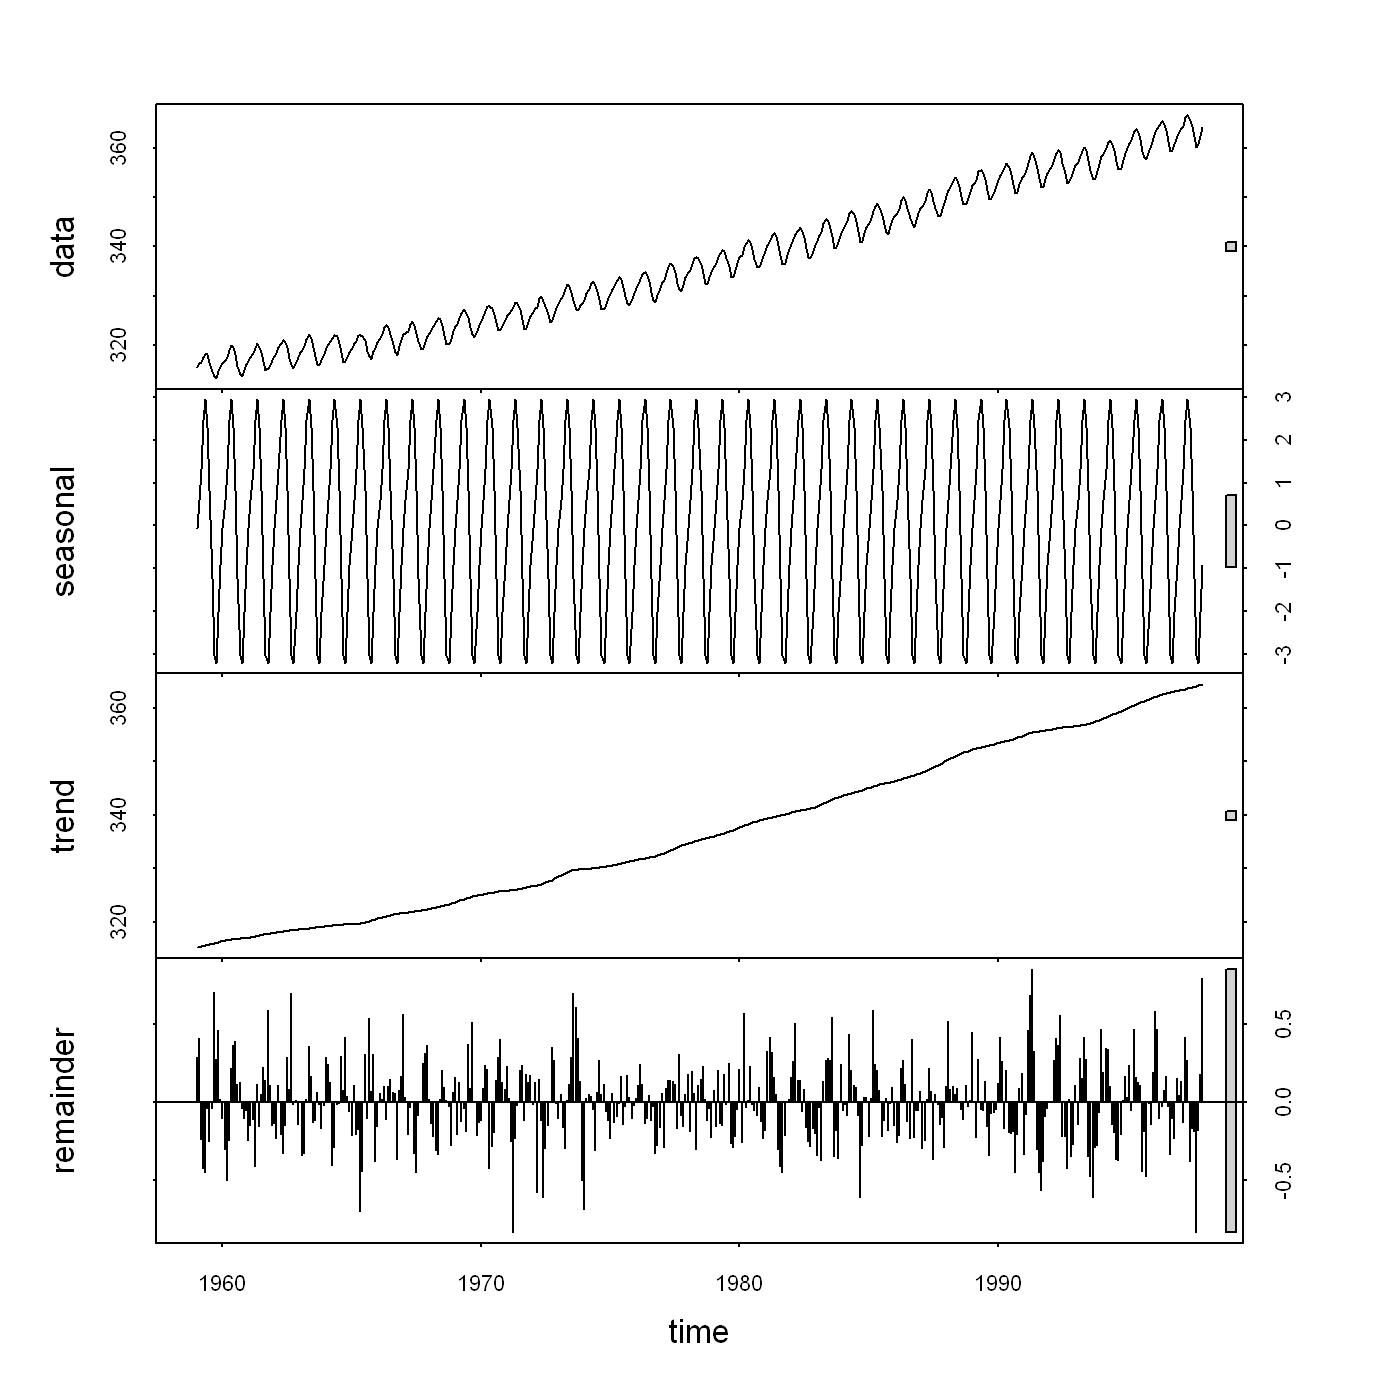

In [66]:
H.stl <- stl(co2,s.window = "periodic")
plot(H.stl)

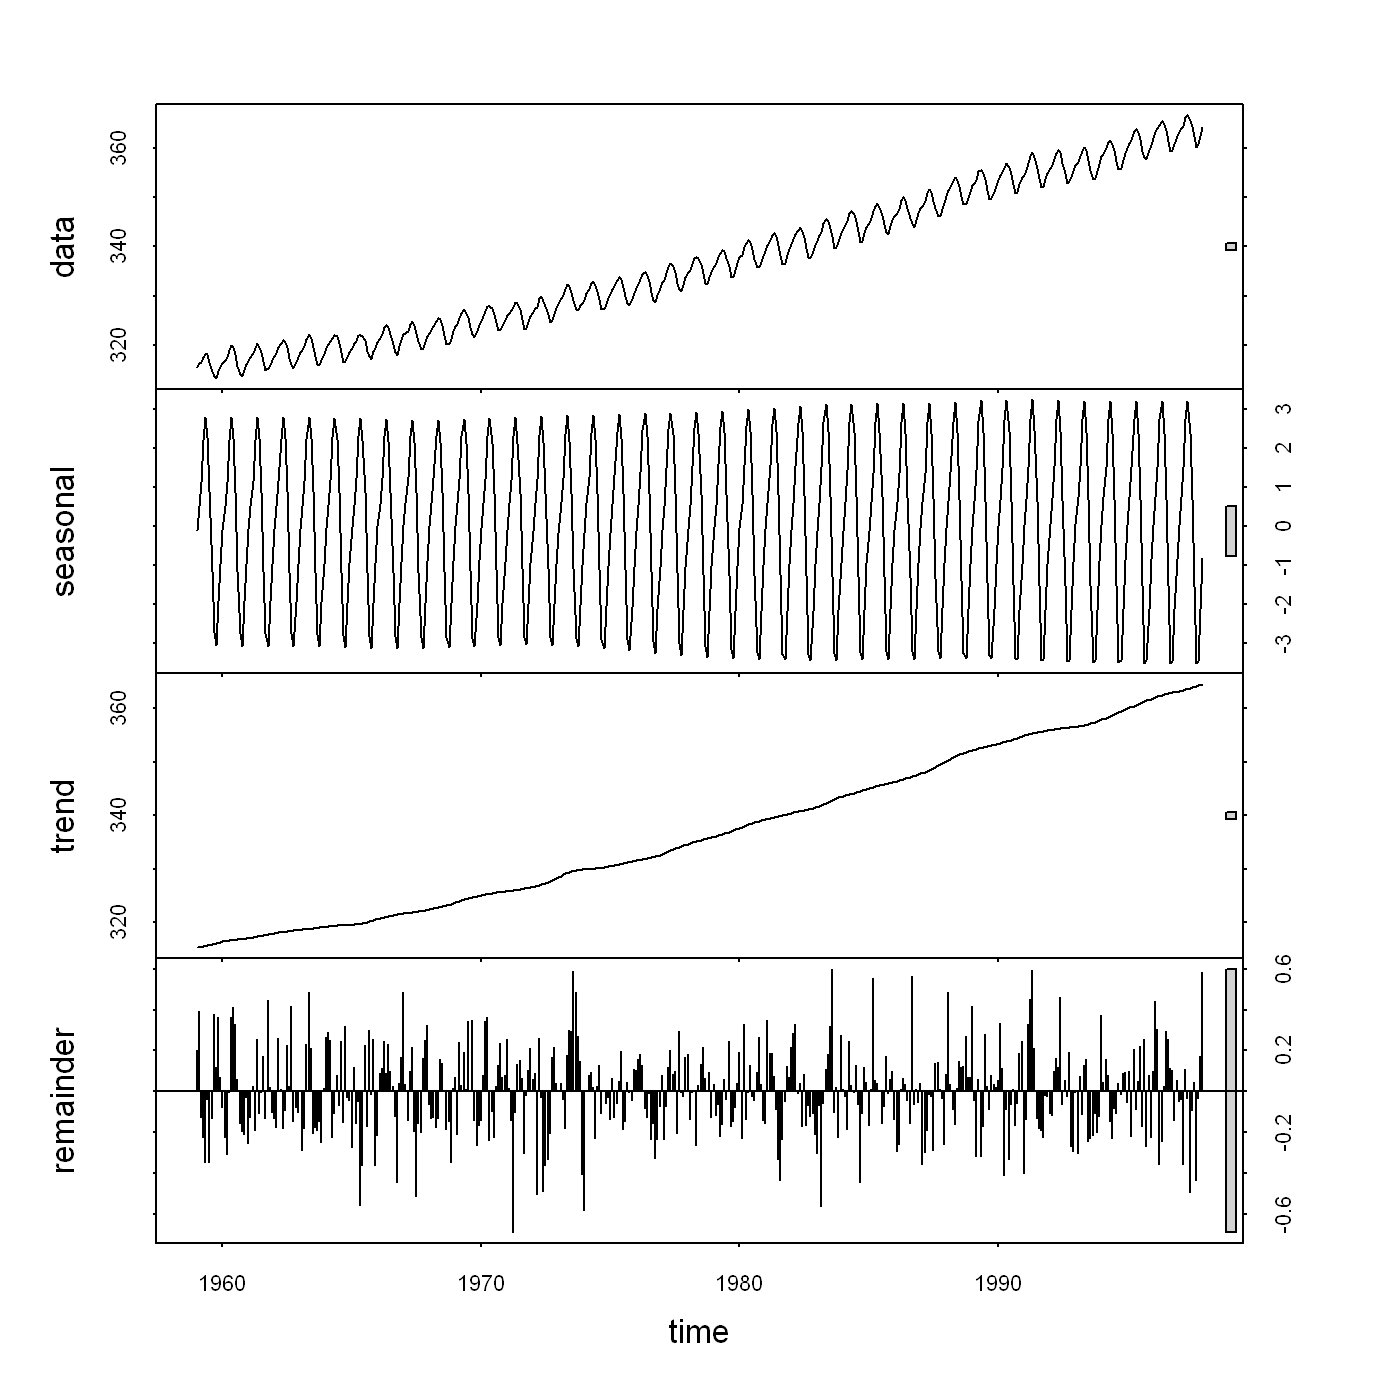

In [62]:
H.stl <- stl(co2,s.window = 13)
plot(H.stl)

In [37]:
H.y <- diff(hstart, lag=12)
H.z <- diff(H.y, lag=1)
H.w <- diff(hstart, lag=1)
H.u <- diff(H.w, lag=12)

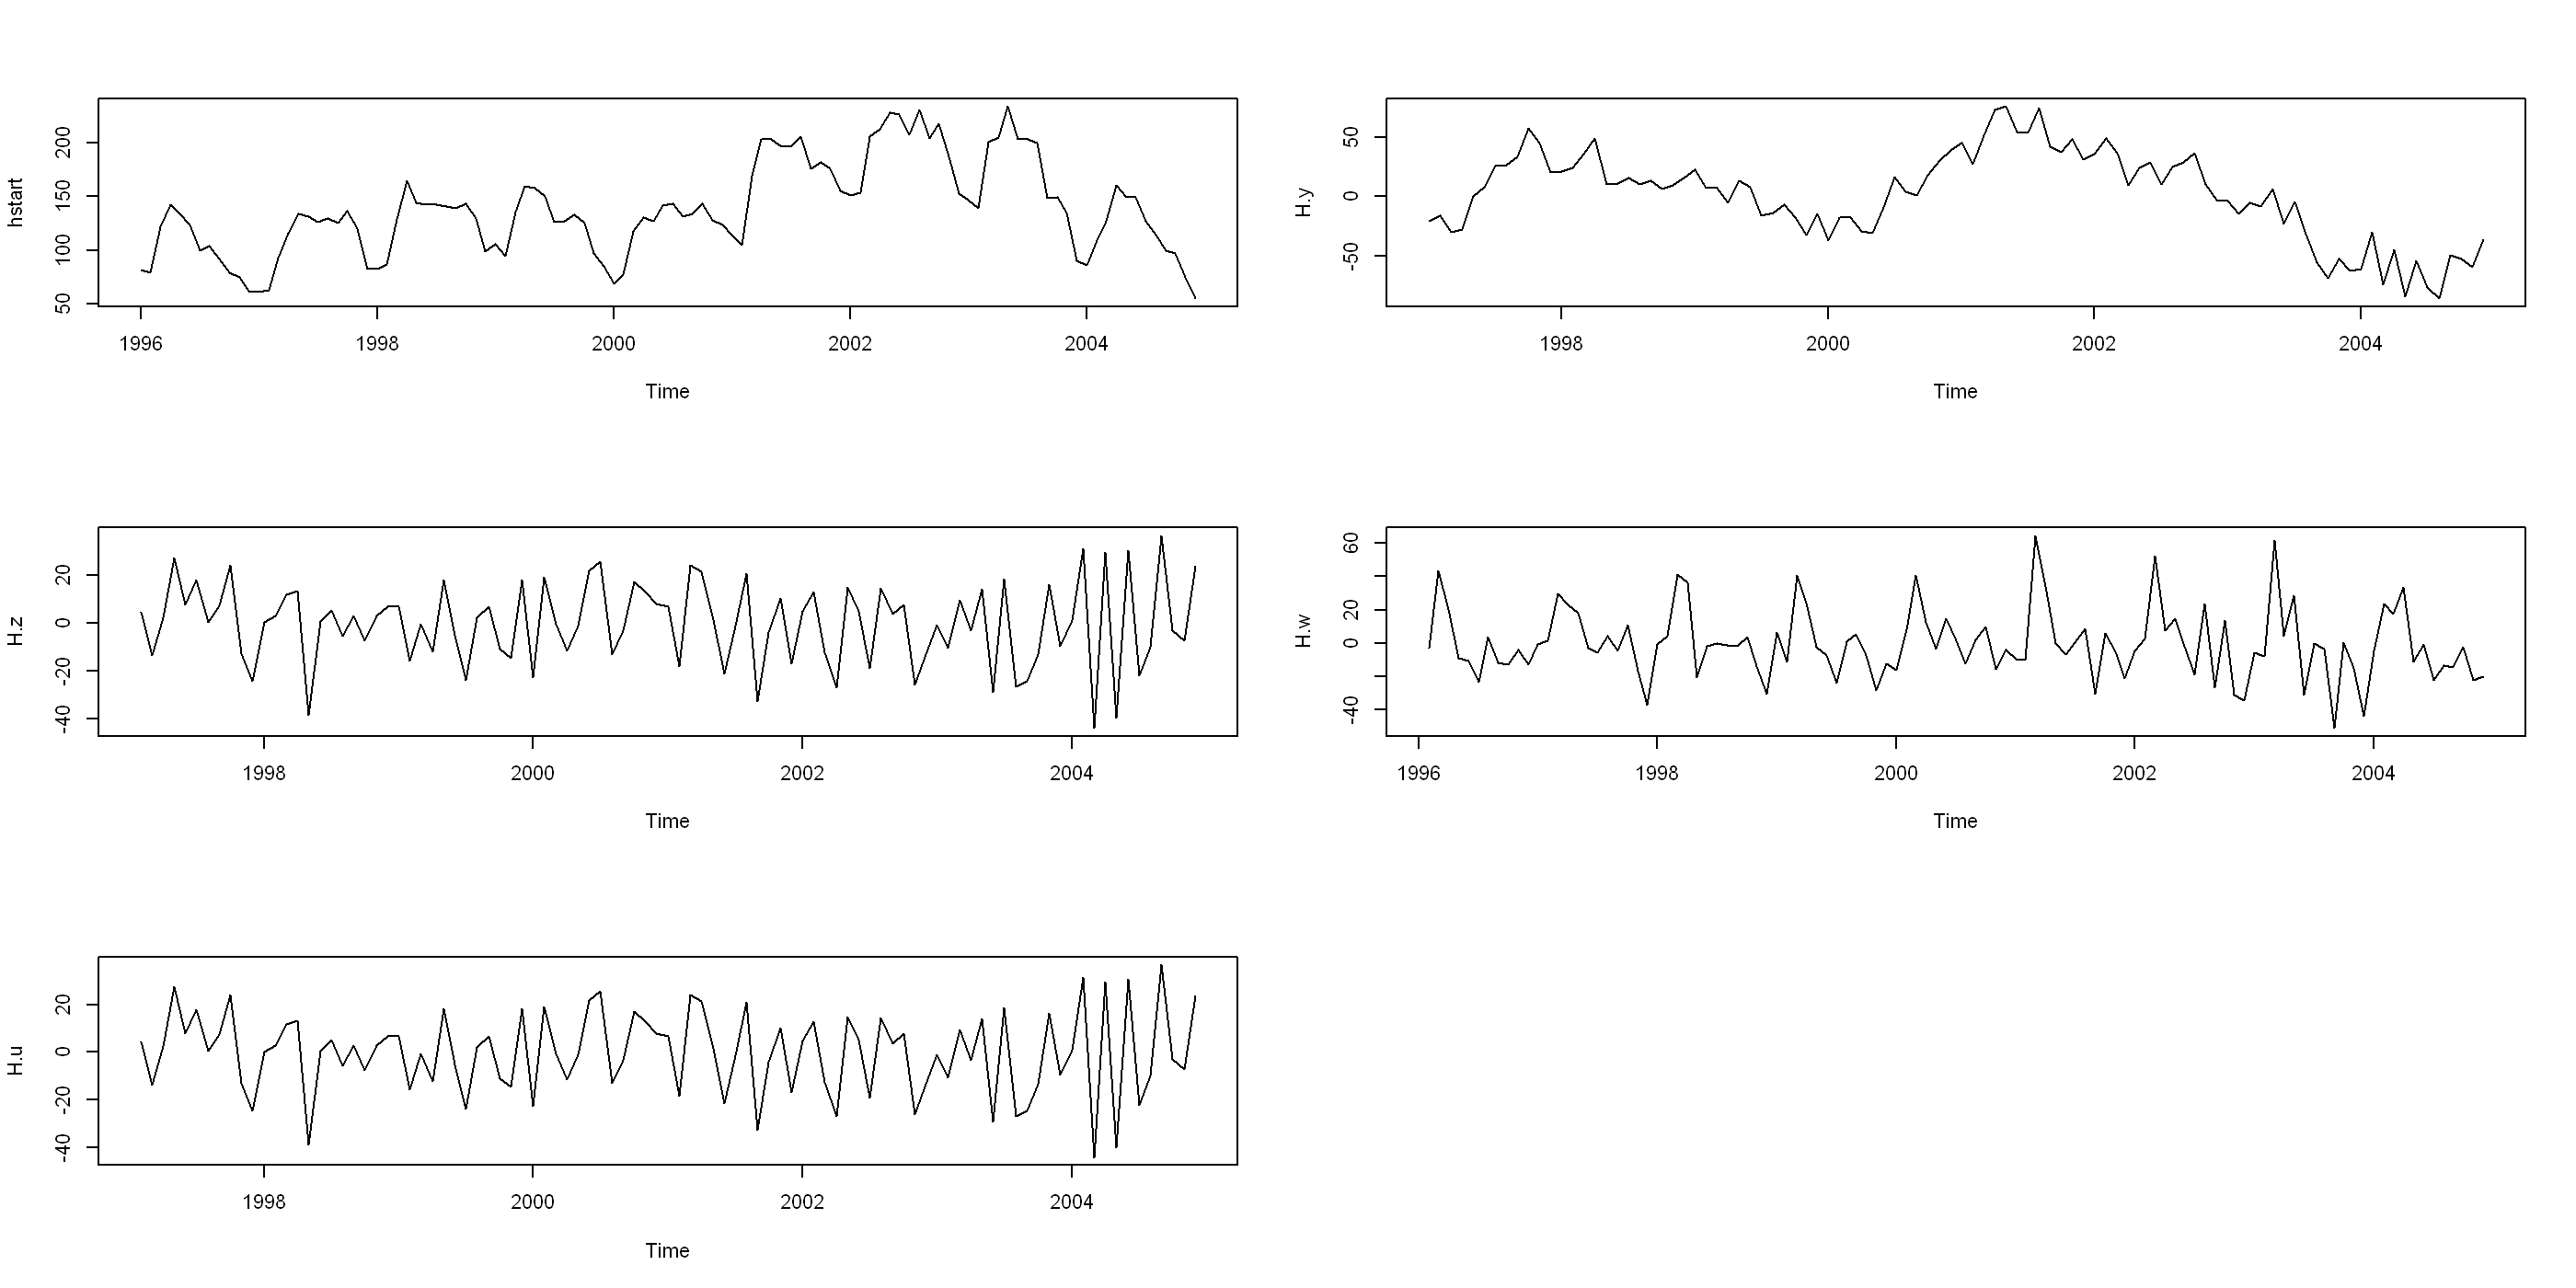

In [38]:
par(mfrow = c(3,2))
plot(hstart)
plot(H.y)
plot(H.z)
plot(H.w)
plot(H.u)

In [39]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

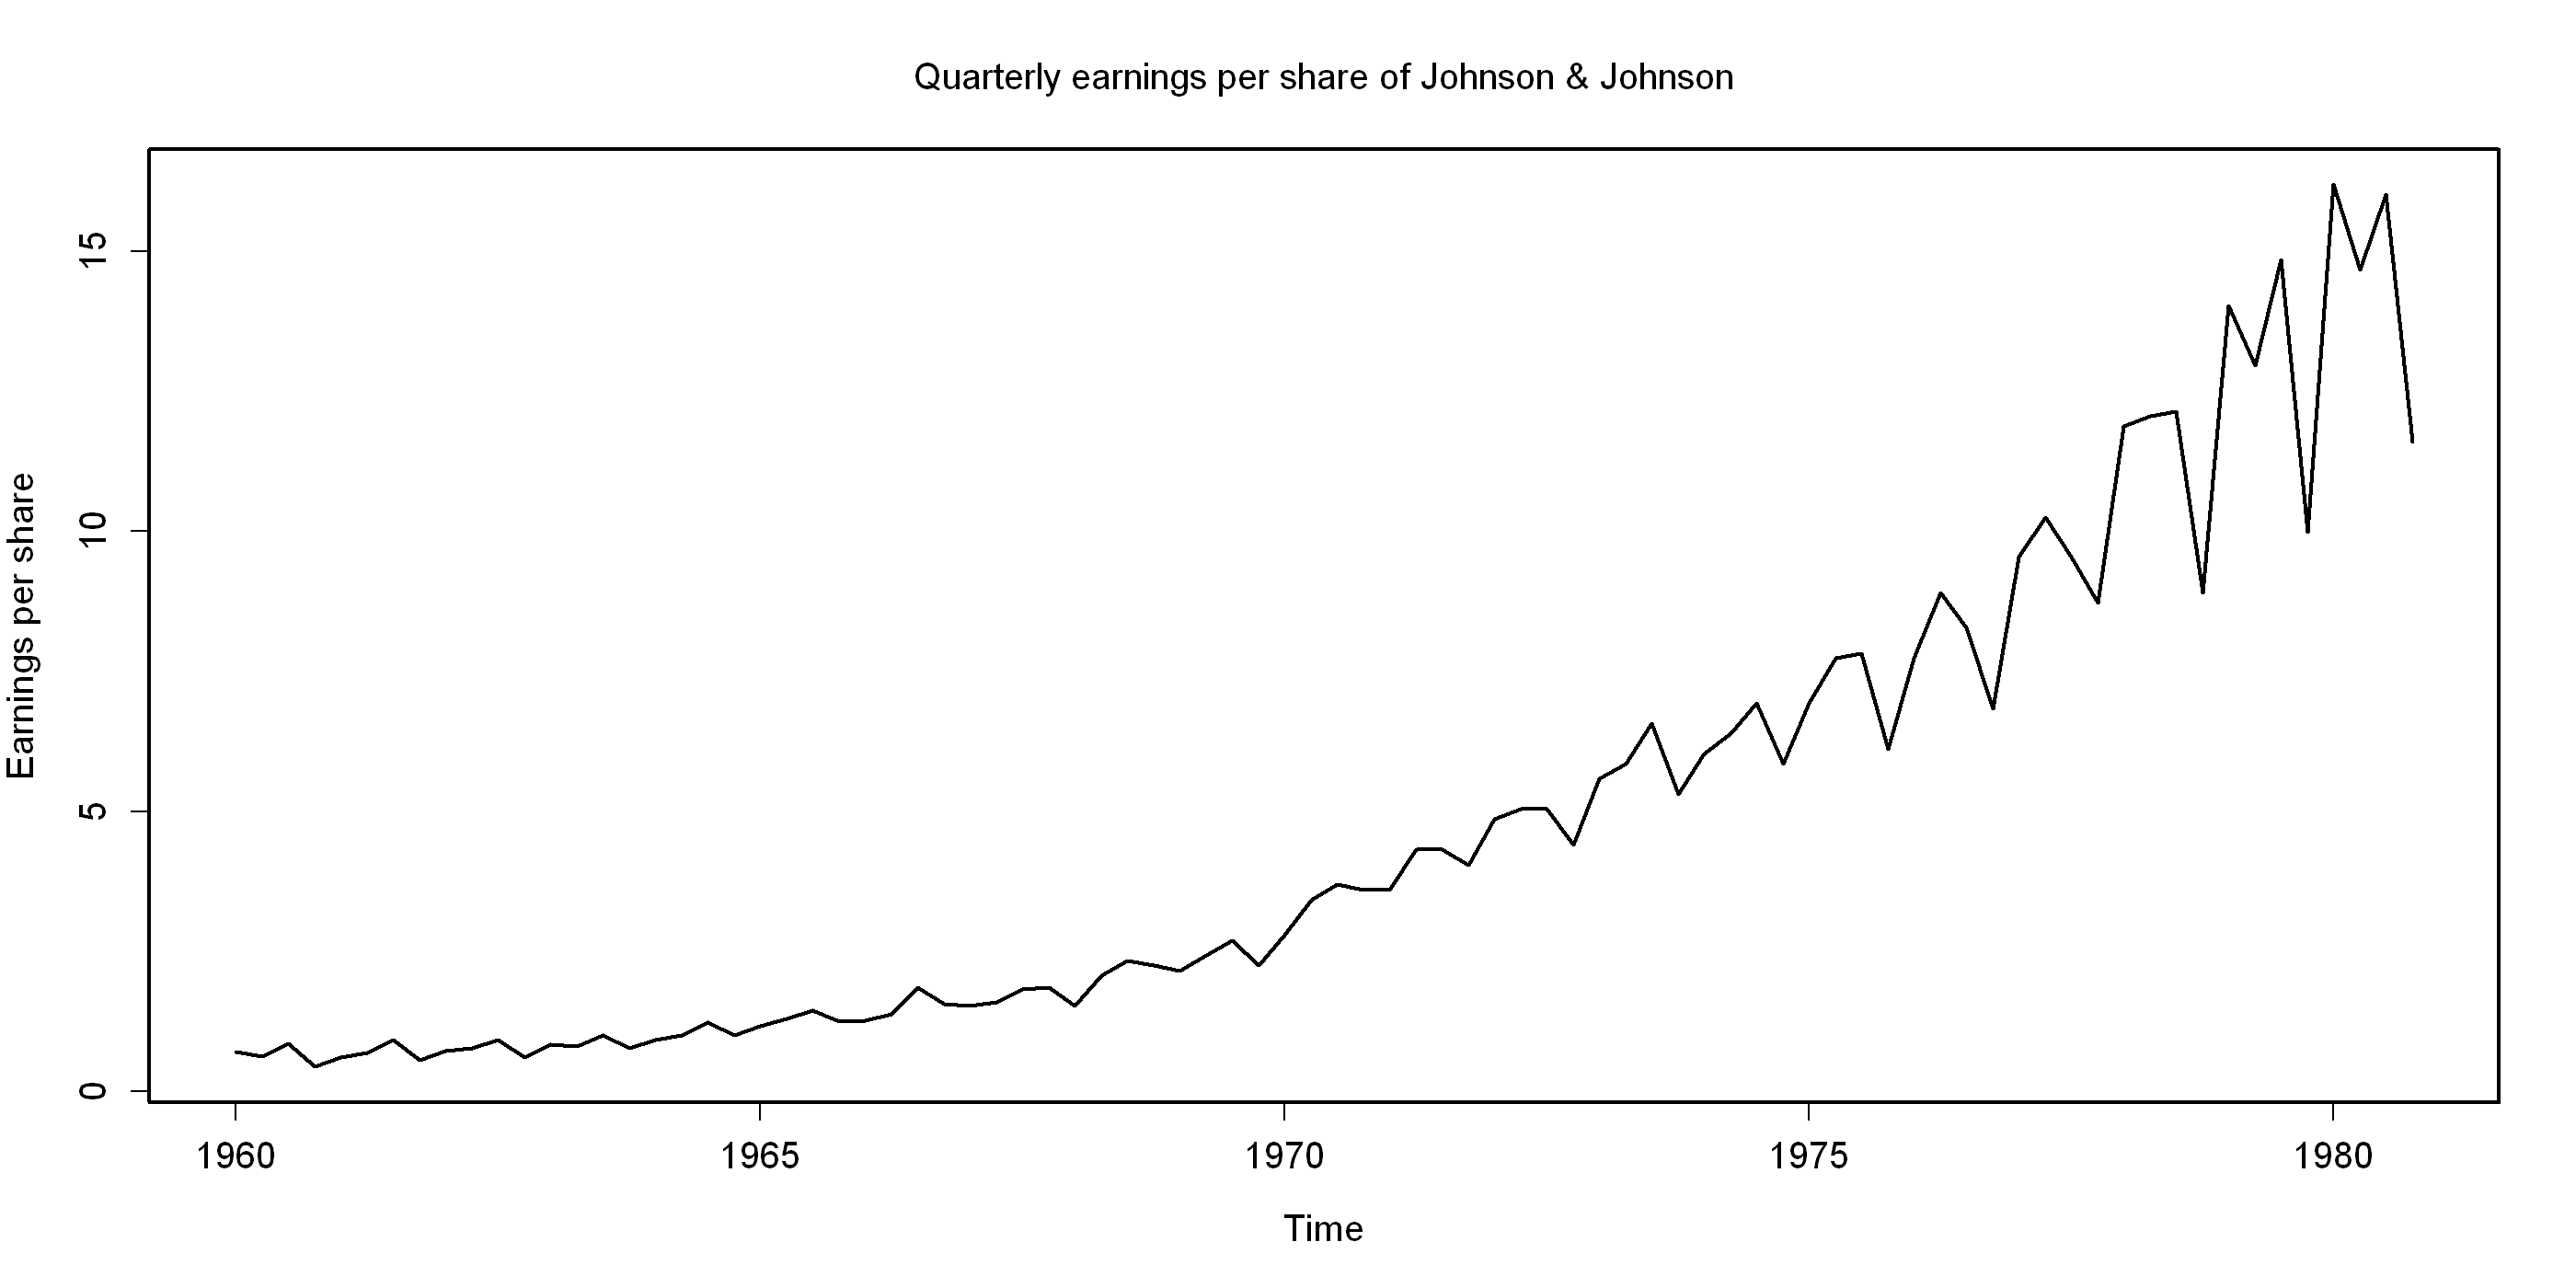

In [40]:
par(mfrow=c(1,1),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2)
plot(JohnsonJohnson,main="Quarterly earnings per share of Johnson & Johnson", ylab = "Earnings per share")

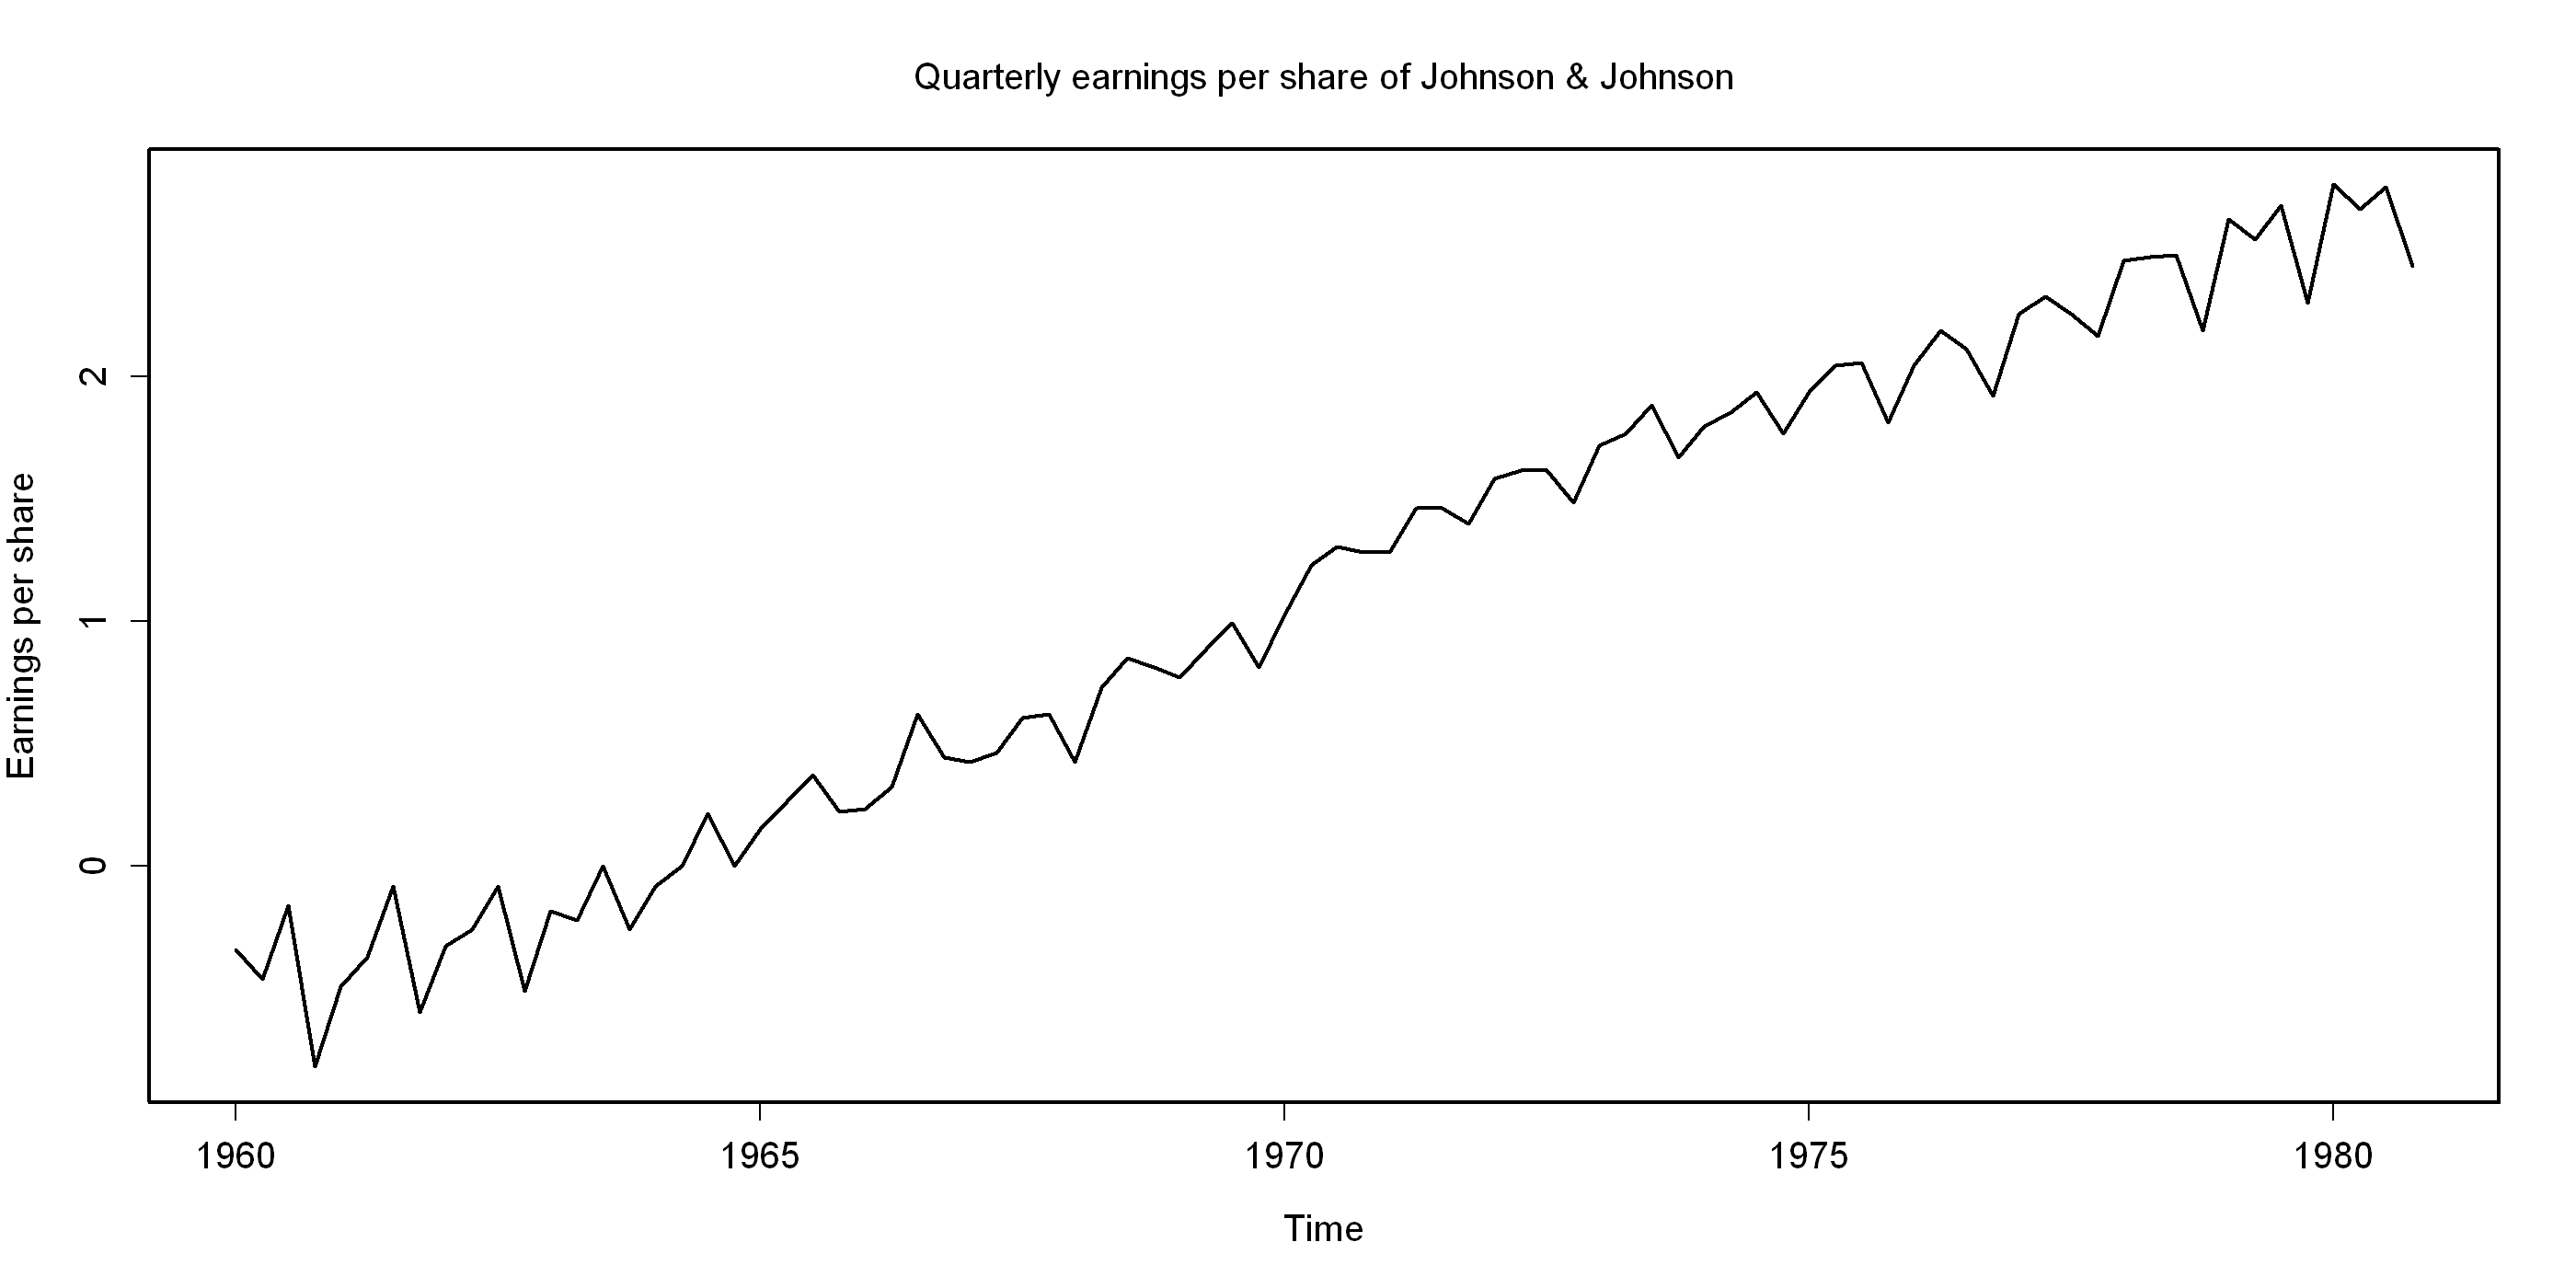

In [41]:
par(mfrow=c(1,1),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2)
plot(log(JohnsonJohnson),main="Quarterly earnings per share of Johnson & Johnson", ylab = "Earnings per share")

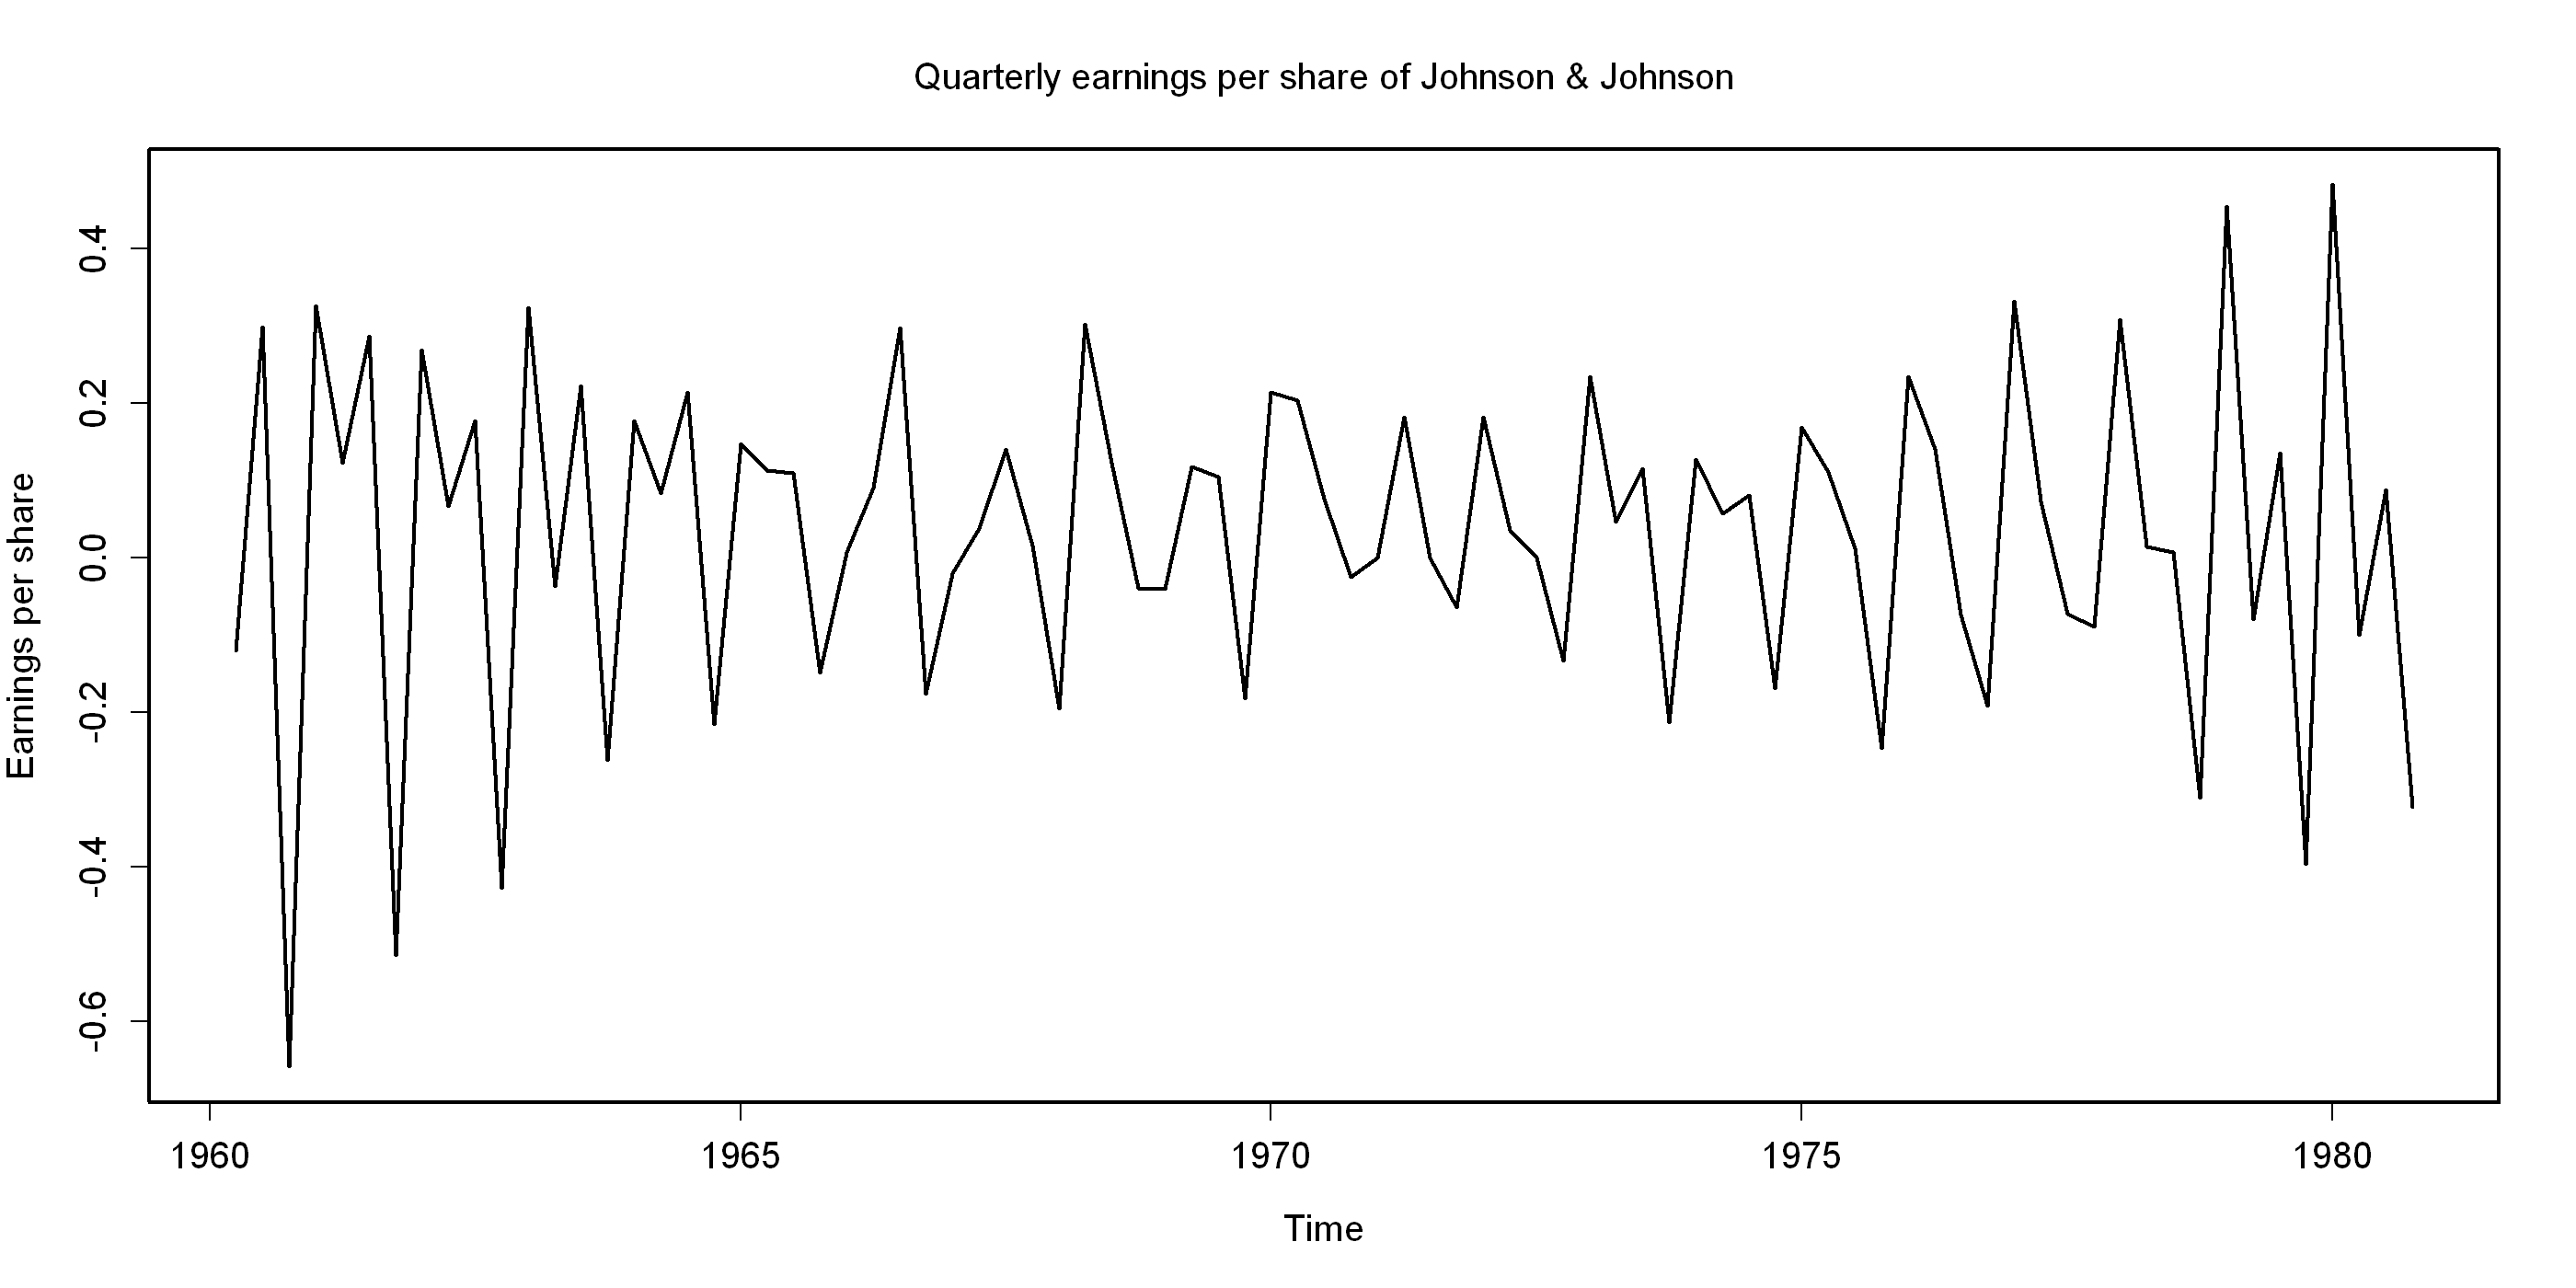

In [42]:
par(mfrow=c(1,1),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2)
plot(diff(log(JohnsonJohnson)),main="Quarterly earnings per share of Johnson & Johnson", ylab = "Earnings per share")

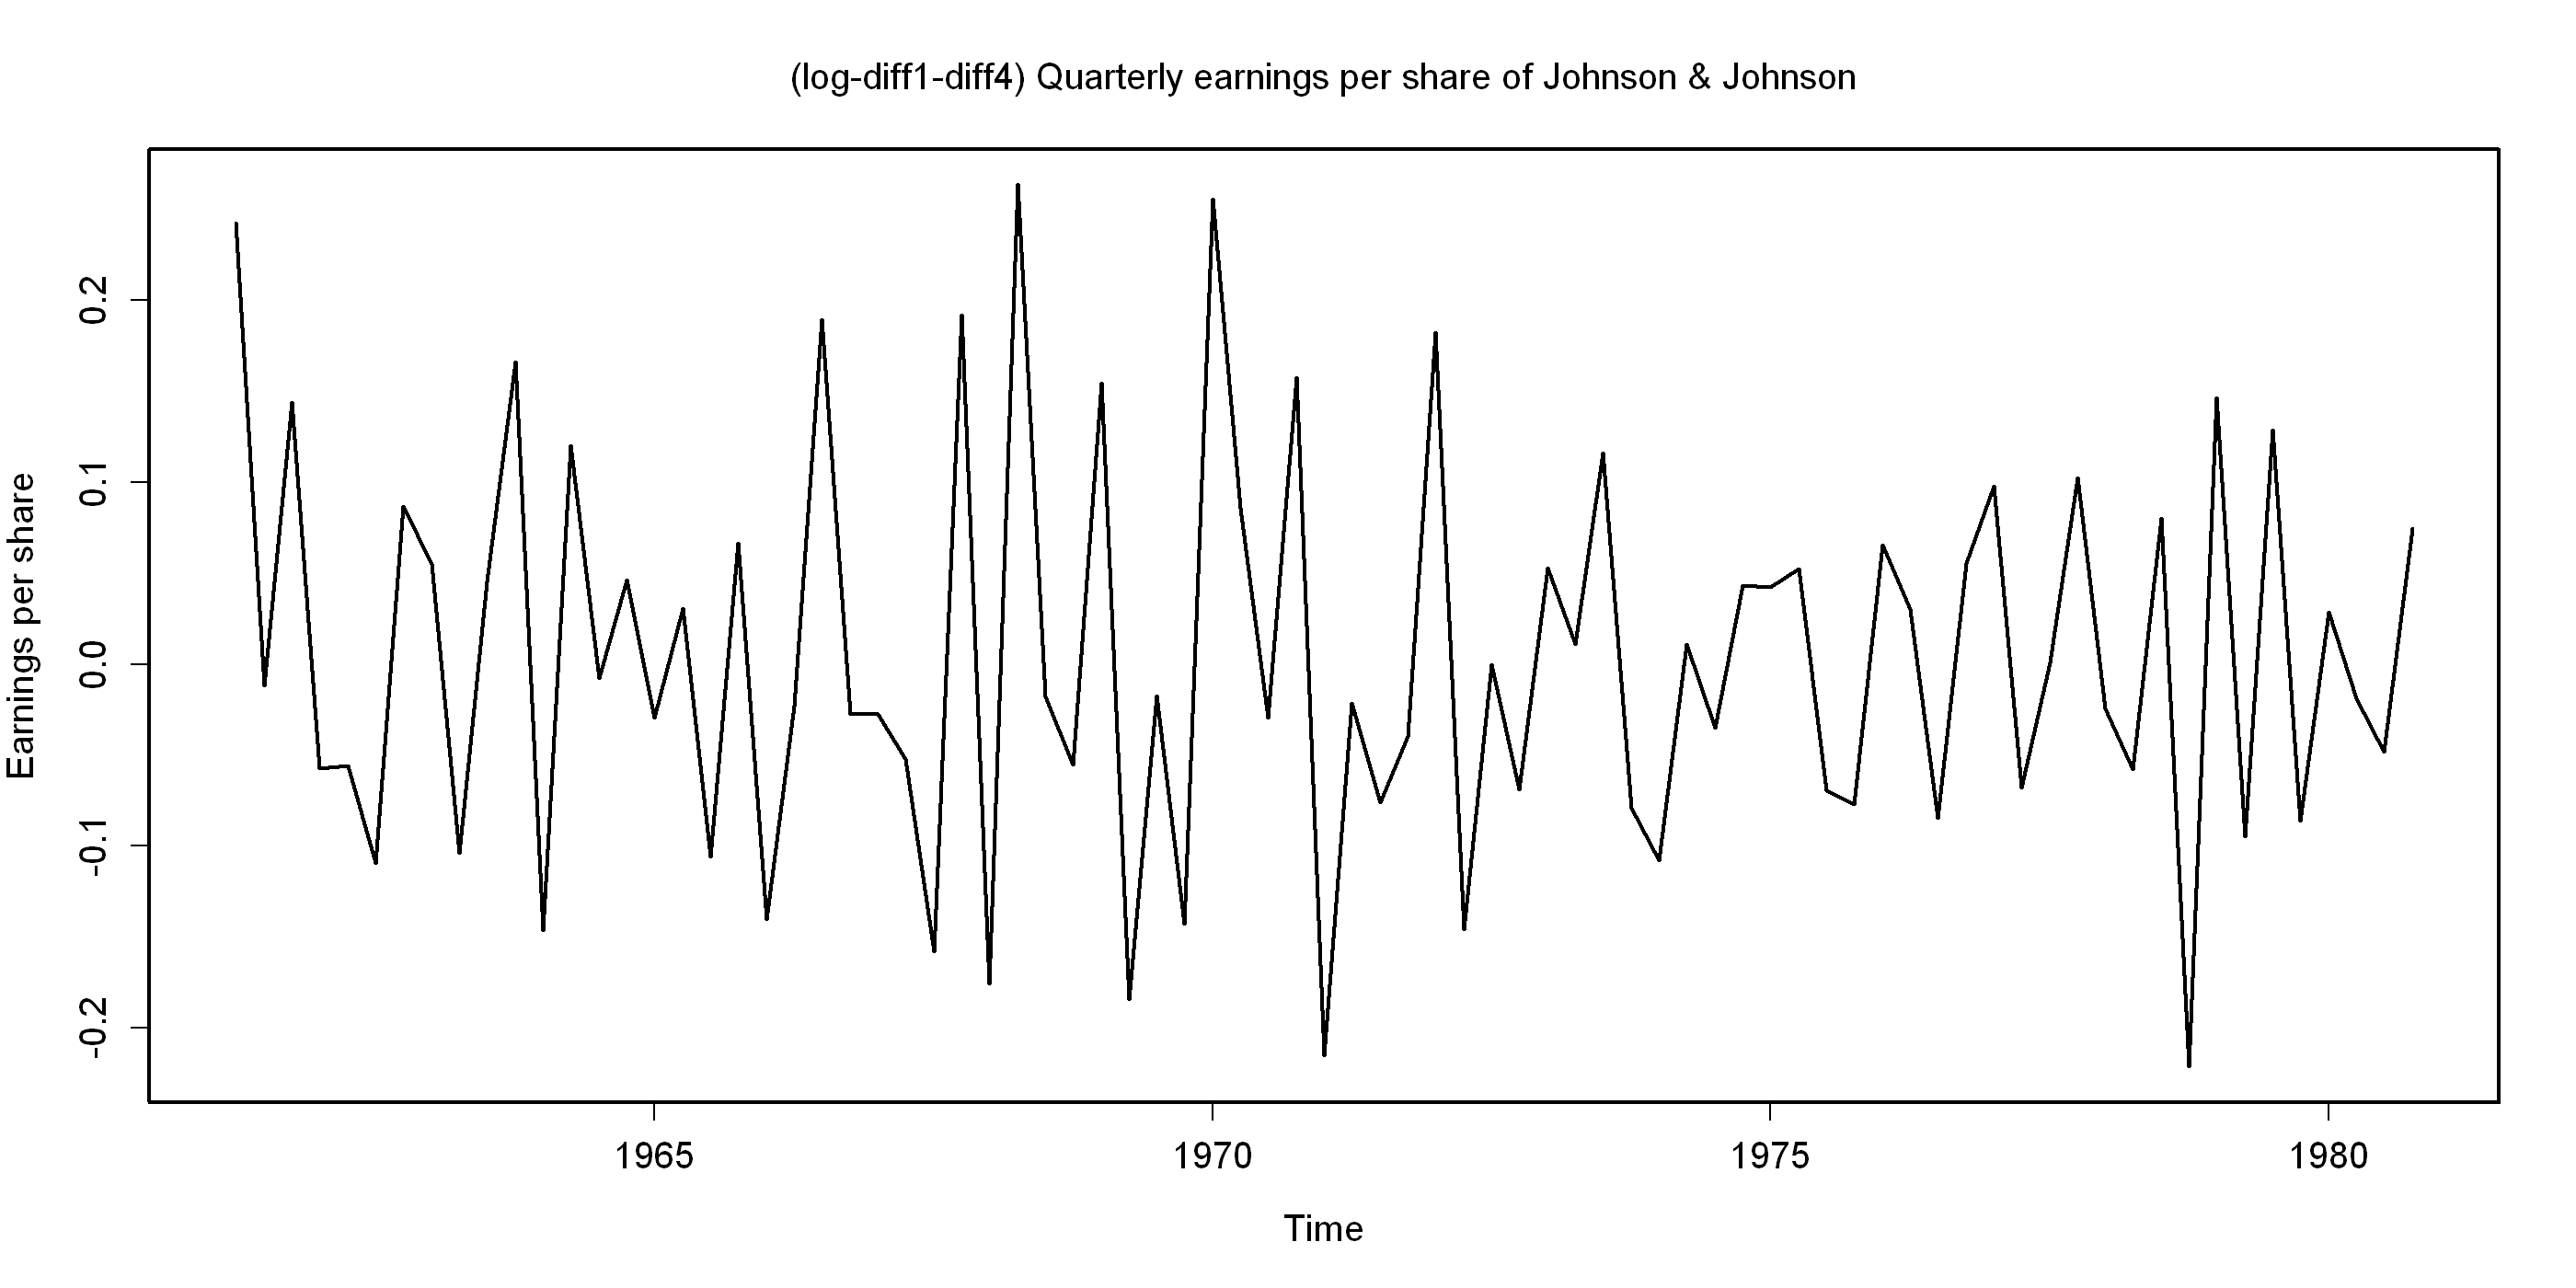

In [43]:
par(mfrow=c(1,1),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2)
plot(diff(diff(log(JohnsonJohnson)),lag=4),main="(log-diff1-diff4) Quarterly earnings per share of Johnson & Johnson", ylab = "Earnings per share")